SISTECH 2026 — MLOps Hands-On 2
## Membangun Mesin Prediksi & Continual Learning untuk Risk Score

Selamat datang di **Hands-On 2**! 🎉 Kalau di Hands-On 1 fokusnya adalah menyiapkan
data (EDA, feature engineering, pseudo-labeling Risk Score), di sini fokusnya adalah
**membangun mesin prediksi**: model yang belajar memetakan fitur ruang–waktu menjadi
Risk Score, sekaligus mampu **diperbarui seiring datangnya data baru**.

**Alur yang akan kita lalui:**
1. Load dataset fitur + label dari Hands-On 1
2. **Baseline non-ML** — patokan minimal sebelum melatih model apa pun
3. **Feature Vector Assembly** — merakit fitur jadi input yang konsisten
4. **Model regresi** — melatih model untuk memprediksi Risk Score
5. **Evaluasi model** — dibandingkan eksplisit dengan baseline
6. **Simulasi continual learning** — data datang bertahap dalam beberapa batch
7. **Drift detection** — mendeteksi kapan data baru "berbeda" secara signifikan
8. **Checkpoint retraining & model versioning** — retrain bersyarat + rekam jejak model

> 🧭 **Prinsip inti:** model yang bagus di hari pertama bisa outdated di hari ke-100.
> MLOps bukan cuma soal melatih model sekali, tapi soal membangun **siklus** yang membuat
> model tetap relevan — dan **jujur mencatat** kapan siklus itu berhasil atau gagal.

---

> ## ⚠️ Cara memakai notebook ini — BACA DULU
>
> Sama seperti Tutorial 1, notebook ini **sengaja dibuat sebagai versi paling sederhana**.
> Ia berjalan dari atas sampai bawah dan menghasilkan model + rekam jejak versi, **tapi
> banyak keputusannya sengaja dibuat seadanya** supaya kalian bisa melihat *mekanismenya
> bekerja* — bukan supaya kalian menyalinnya bulat-bulat.
>
> Sepanjang notebook kalian akan menemukan dua jenis blok:
> - 🔧 **Versi Sederhana (Baseline)** — kode yang berfungsi tapi jelas belum optimal.
> - 🙋 **Giliran Kalian** — di sinilah kalian mengambil alih: mengembangkan, mengganti,
>   atau memperbaiki versi sederhana tadi, lalu **menjustifikasinya di laporan**.
>
> Bagian yang paling besar bobot penilaiannya (**continual learning**, 35%) justru yang
> paling "mentah" di sini. **Nilai kalian datang dari seberapa jauh kalian mengembangkannya,
> bukan dari menjalankan notebook ini apa adanya.**

# 0. Installation & Setup

Kita memakai stack standar data science + ML: `pandas`, `numpy`, `matplotlib`, `seaborn`,
`scikit-learn`, `scipy`, dan `joblib` (untuk menyimpan model/checkpoint).

In [25]:
# Jalankan sekali saja (di Colab biasanya sudah tersedia)
!pip install -q scikit-learn scipy joblib pandas numpy matplotlib seaborn

In [26]:
import os
import json
import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import ks_2samp

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
np.random.seed(42)
print("Setup selesai ✅")

Setup selesai ✅


# 1. Load Dataset Fitur + Label dari Hands-On 1

Kita melanjutkan **langsung** dari `features_labels.csv` yang dihasilkan di akhir
Hands-On 1: dataset dengan satu baris per unit analisis (sel grid × hari × jam),
berisi fitur ruang–waktu dan label `risk_score` (0–100).

**README**: Langkah pertama adalah mengunduh `features_labels.csv` dari Files notebook Hands-On 1 lalu upload ke project session ini. Upload dapat ditemukan di Files.

Icon Files:

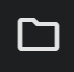

Icon Upload:

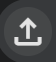

In [27]:
DATA_PATH = "features_labels.csv"  # ganti path ini kalau file kalian ada di lokasi lain

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Dataset dari Hands-On 1 berhasil dimuat: {df.shape}")
else:
    # -----------------------------------------------------------------------
    # ⚠️ FALLBACK: dataset sintetis KECIL agar notebook ini tetap bisa dijalankan
    # end-to-end walau kalian belum mengunggah file dari Hands-On 1.
    # JANGAN pakai data sintetis ini untuk mengerjakan tugas — ganti DATA_PATH
    # di atas dengan file `features_labels.csv` (atau .parquet) hasil HO1 kalian.
    # -----------------------------------------------------------------------
    print(f"'{DATA_PATH}' tidak ditemukan. Membuat dataset SINTETIS untuk demo notebook...")
    rng = np.random.default_rng(0)
    n_cells = 150
    lat_r = rng.uniform(41.65, 42.00, n_cells).round(2)
    lon_r = rng.uniform(-87.90, -87.55, n_cells).round(2)
    cell_ids = [f"{la}_{lo}" for la, lo in zip(lat_r, lon_r)]

    rows = []
    for cid, la, lo in zip(cell_ids, lat_r, lon_r):
        for dow in range(7):
            for hour in range(0, 24, 3):  # subset jam biar ringkas
                crime_count = rng.poisson(3) + 1
                base = 10 + 40 * (np.sin(np.deg2rad(hour * 15)) + 1) / 2
                base += 15 * (1 if dow >= 5 else 0)
                base += crime_count * 1.5
                risk_score = float(np.clip(base + rng.normal(0, 5), 0, 100))
                rows.append({
                    "cell_id": cid, "lat_r": la, "lon_r": lo,
                    "dow": dow, "hour": hour,
                    "hour_sin": np.sin(2*np.pi*hour/24), "hour_cos": np.cos(2*np.pi*hour/24),
                    "dow_sin": np.sin(2*np.pi*dow/7), "dow_cos": np.cos(2*np.pi*dow/7),
                    "crime_count": crime_count, "risk_score": risk_score,
                })
    df = pd.DataFrame(rows)
    print(f"Dataset sintetis dibuat: {df.shape}")

df.head()

Dataset dari Hands-On 1 berhasil dimuat: (433002, 14)


,cell_id,lat_r,lon_r,dow,hour,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,crime_count,crime_diversity,arrest_rate,risk_score
0,41.645_-87.54,41.645,-87.54,0,5,0.965926,0.258819,0.000000,1.000000,0,1,1,0.0,55.646631
1,41.645_-87.54,41.645,-87.54,0,9,0.707107,-0.707107,0.000000,1.000000,0,2,1,0.0,57.292018
2,41.645_-87.54,41.645,-87.54,1,0,0.000000,1.000000,0.781831,0.623490,0,1,1,1.0,57.338843
3,41.645_-87.54,41.645,-87.54,1,9,0.707107,-0.707107,0.781831,0.623490,0,1,1,0.0,59.563203
4,41.645_-87.54,41.645,-87.54,2,7,0.965926,-0.258819,0.974928,-0.222521,0,1,1,0.0,47.001420


In [28]:
df.describe().round(2)

,lat_r,lon_r,dow,hour,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,crime_count,crime_diversity,arrest_rate,risk_score
count,433002.00,433002.00,433002.00,433002.00,433002.00,433002.00,433002.00,433002.00,433002.00,433002.00,433002.00,433002.00,433002.00
mean,41.84,-87.67,3.01,12.86,-0.16,-0.05,-0.01,-0.01,0.29,1.20,1.12,0.15,54.58
std,0.09,0.06,2.00,6.67,0.69,0.71,0.71,0.71,0.45,0.71,0.39,0.34,4.17
min,41.64,-87.94,0.00,0.00,-1.00,-1.00,-0.97,-0.90,0.00,1.00,1.00,0.00,0.00
25%,41.77,-87.71,1.00,8.00,-0.87,-0.71,-0.78,-0.90,0.00,1.00,1.00,0.00,52.28
50%,41.86,-87.66,3.00,14.00,-0.26,-0.00,0.00,-0.22,0.00,1.00,1.00,0.00,54.52
75%,41.91,-87.63,5.00,18.00,0.50,0.71,0.78,0.62,1.00,1.00,1.00,0.00,56.82
max,42.02,-87.52,6.00,23.00,1.00,1.00,0.97,1.00,1.00,39.00,8.00,1.00,100.00


### Distribusi Risk Score

Sekilas cek ulang bentuk distribusi label sebelum melatih model apa pun — ini bekal
untuk memilih metrik evaluasi dan menafsirkan hasil nanti.

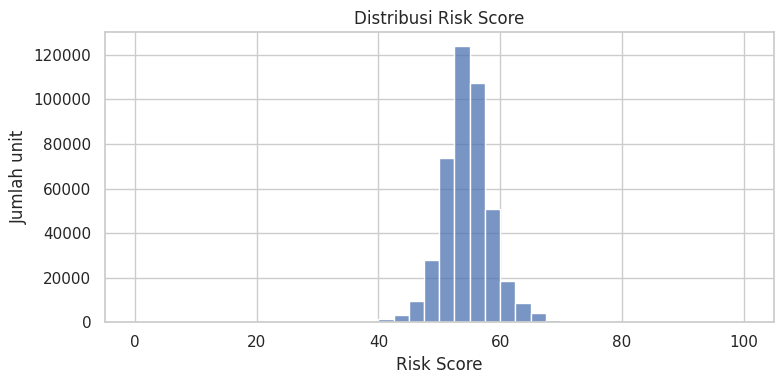

In [29]:
plt.figure(figsize=(8, 4))
sns.histplot(df["risk_score"], bins=40, color="#4C72B0")
plt.title("Distribusi Risk Score")
plt.xlabel("Risk Score"); plt.ylabel("Jumlah unit")
plt.tight_layout(); plt.show()

# 2. Baseline Non-ML — Historical Average

Sebelum melatih model ML apa pun, kita butuh **baseline**: prediktor sederhana yang
menjadi patokan minimal. Baseline menjawab pertanyaan kritis secara empiris: *apakah
model yang lebih kompleks benar-benar memberi nilai tambah dibanding pendekatan yang
jauh lebih sederhana?*

Pertanyaannya: apa prediksi paling logis untuk Risk Score suatu lokasi & waktu, kalau
kita **hanya** berbekal pola historis, tanpa melatih model ML sama sekali?

> 🔧 **Versi Sederhana (Baseline).** Kita coba tiga versi paling lugas:
> - **Global mean** — rata-rata Risk Score dari seluruh data training (mengabaikan
>   lokasi & waktu sama sekali).
> - **Rata-rata per sel** — pola spasial: "lokasi ini secara historis seberapa rawan?"
> - **Rata-rata per (hari, jam)** — pola temporal: "jam & hari ini secara historis
>   seberapa rawan, di mana pun lokasinya?"

In [30]:
TARGET_COL = "risk_score"

# Split evaluasi: 80% train, 20% test (acak, untuk evaluasi model & baseline statis)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"train_df: {train_df.shape}  |  test_df: {test_df.shape}")

train_df: (346401, 14)  |  test_df: (86601, 14)


In [31]:
def evaluate(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"model": label, "MAE": mae, "RMSE": rmse, "R2": r2}

results = []

# --- Baseline 1: global mean ---
global_mean = train_df[TARGET_COL].mean()
pred_global = np.full(len(test_df), global_mean)
results.append(evaluate(test_df[TARGET_COL], pred_global, "Baseline: Global Mean"))

# --- Baseline 2: rata-rata per sel (pola spasial) ---
cell_mean_map = train_df.groupby("cell_id")[TARGET_COL].mean()
pred_cell = test_df["cell_id"].map(cell_mean_map).fillna(global_mean).values
results.append(evaluate(test_df[TARGET_COL], pred_cell, "Baseline: Rata-rata per Sel"))

# --- Baseline 3: rata-rata per (hari, jam) (pola temporal) ---
hourdow_mean_map = train_df.groupby(["dow", "hour"])[TARGET_COL].mean()
idx = pd.MultiIndex.from_frame(test_df[["dow", "hour"]])
pred_hourdow = hourdow_mean_map.reindex(idx).values
pred_hourdow = np.where(np.isnan(pred_hourdow), global_mean, pred_hourdow)
results.append(evaluate(test_df[TARGET_COL], pred_hourdow, "Baseline: Rata-rata per Jam+Hari"))

baseline_results_df = pd.DataFrame(results)
baseline_results_df.round(3)

,model,MAE,RMSE,R2
0,Baseline: Global Mean,3.022,4.159,-0.000
1,Baseline: Rata-rata per Sel,2.718,3.707,0.205
2,Baseline: Rata-rata per Jam+Hari,2.906,3.999,0.075


### 🙋 Giliran Kalian — Baseline

Ini bagian yang **dinilai** sebagai bagian dari Baseline & Feature Vector Assembly (15%):
- Baseline mana yang paling kuat di data kalian? Menurut kalian **kenapa**?
- Coba **kombinasikan** dua pola sekaligus, misalnya rata-rata per (sel, jam) atau
  (sel, hari) — apakah lebih baik daripada memakai satu pola saja?
- Bagaimana strategi *fallback* kalau kombinasi (sel, jam, hari) tertentu tidak pernah
  muncul di data training (seperti yang kita tangani dengan `global_mean` di atas)?
- **Justifikasi** baseline pilihan kalian di laporan — baseline yang "masuk akal" jauh
  lebih penting daripada baseline yang "paling kompleks".

### 2.1 Baseline terkuat

Dari tiga baseline dasar, Rata rata per Sel adalah yang paling kuat, dengan MAE 2.718, RMSE 3.707, dan R2 0.205, semuanya lebih baik dibanding dua baseline lainnya.

Alasannya adalah karena MAE dan RMSE Rata rata per Sel paling kecil, artinya rata rata selisih prediksi terhadap nilai sebenarnya paling sedikit dibanding Global Mean maupun Rata rata per Jam+Hari. R2 nya juga paling besar, yaitu 0.205, artinya baseline ini mampu menjelaskan sekitar 20.5 persen variasi risk score, sementara Rata rata per Jam + Hari hanya sekitar 7.5 persen, dan Global Mean nyaris nol karena memang tidak memakai informasi apa pun selain rata rata keseluruhan.

Ini menunjukkan bahwa risk score di dataset saya lebih banyak ditentukan oleh karakteristik lokasi (sel), dibanding oleh pola waktu (jam atau hari). Dengan kata lain, sebuah lokasi cenderung punya tingkat risiko historis yang konsisten dari waktu ke waktu, sedangkan variasi menurut jam atau hari dalam seminggu jauh lebih kecil pengaruhnya terhadap risk score dibanding faktor lokasi itu sendiri.

### 2.2 Kombinasikan dua pola

#### 2.2.1 Sel, Jam

In [32]:
cell_hour_mean_map = train_df.groupby(["cell_id", "hour"])[TARGET_COL].mean()

def predict_cell_hour(row):
    key = (row["cell_id"], row["hour"])
    if key in cell_hour_mean_map.index:
        return cell_hour_mean_map.loc[key]
    if row["cell_id"] in cell_mean_map.index:
        return cell_mean_map.loc[row["cell_id"]]
    return global_mean

pred_cell_hour = test_df.apply(predict_cell_hour, axis=1).values
results.append(evaluate(test_df[TARGET_COL], pred_cell_hour, "Baseline: Kombinasi (Sel, Jam)"))

#### 2.2.2 Sel, Hari

In [33]:
cell_dow_mean_map = train_df.groupby(["cell_id", "dow"])[TARGET_COL].mean()

def predict_cell_dow(row):
    key = (row["cell_id"], row["dow"])
    if key in cell_dow_mean_map.index:
        return cell_dow_mean_map.loc[key]
    if row["cell_id"] in cell_mean_map.index:
        return cell_mean_map.loc[row["cell_id"]]
    return global_mean

pred_cell_dow = test_df.apply(predict_cell_dow, axis=1).values
results.append(evaluate(test_df[TARGET_COL], pred_cell_dow, "Baseline: Kombinasi (Sel, Hari)"))

#### 2.2.3 Sel, Weekend

In [34]:
cell_weekend_mean_map = train_df.groupby(["cell_id", "is_weekend"])[TARGET_COL].mean()

def predict_cell_weekend(row):
    key = (row["cell_id"], row["is_weekend"])
    if key in cell_weekend_mean_map.index:
        return cell_weekend_mean_map.loc[key]
    if row["cell_id"] in cell_mean_map.index:
        return cell_mean_map.loc[row["cell_id"]]
    return global_mean

pred_cell_weekend = test_df.apply(predict_cell_weekend, axis=1).values
results.append(evaluate(test_df[TARGET_COL], pred_cell_weekend, "Baseline: Kombinasi (Sel, Weekend)"))

In [35]:
baseline_results_df = pd.DataFrame(results)
baseline_results_df.round(3)

,model,MAE,RMSE,R2
0,Baseline: Global Mean,3.022,4.159,-0.000
1,Baseline: Rata-rata per Sel,2.718,3.707,0.205
2,Baseline: Rata-rata per Jam+Hari,2.906,3.999,0.075
3,"Baseline: Kombinasi (Sel, Jam)",2.924,3.993,0.078
4,"Baseline: Kombinasi (Sel, Hari)",3.048,4.126,0.015
5,"Baseline: Kombinasi (Sel, Weekend)",2.810,3.827,0.153


Baseline Rata rata per Sel saja, tanpa dikombinasikan dengan variabel waktu apa pun, tetap menjadi baseline terkuat, dengan MAE 2.718 dan R2 0.205, mengalahkan semua baseline kombinasi termasuk Sel + Jam, Sel + Hari, maupun Sel + Weekend.

Ketika menghitung rata rata per sel saja, tiap sel punya banyak baris data untuk dirata ratakan (gabungan dari 7 hari dan 24 jam), sehingga estimasi rata ratanya stabil dan mendekati nilai historis yang sesungguhnya.

Ketika memecahnya lagi menjadi per (sel, jam) atau per (sel, hari), tiap kombinasi jadi punya jauh lebih sedikit baris data untuk dirata ratakan. Rata rata dari sedikit sampel jadi lebih rentan terhadap noise, artinya rata rata itu bisa jadi hanya kebetulan tinggi atau rendah di data training, dan tidak benar benar mencerminkan pola asli. Saat diuji ke data test, prediksi yang overfit ke noise ini jadi kurang akurat dibanding rata rata per sel yang lebih general dan stabil.

Dengan kata lain, di dataset saya, variasi risk score memang didominasi oleh faktor lokasi (sel), sementara variasi tambahan menurut jam atau hari dalam seminggu terlalu kecil dan terlalu berisik untuk membantu, malah menambah risiko overfitting ketika dipecah terlalu detail.

Baseline Sel + Weekend adalah kombinasi yang paling mendekati performa Rata rata per Sel dibanding kombinasi lain (MAE 2.810 vs 2.718), kemungkinan karena weekend hanya membagi data jadi dua kelompok besar (bukan tujuh hari atau 24 jam), sehingga tiap kelompok masih punya cukup sampel untuk estimasi yang stabil.

### 2.3 Strategi fallback

In [36]:
def fallback_level(row, combo_map, keycols):
    key = tuple(row[c] for c in keycols)
    if key in combo_map.index:
        return "exact"
    if row["cell_id"] in cell_mean_map.index:
        return "per_cell"
    return "global"

print(f"{'model':<15} {'exact match':<15} {'fallback ke rata-rata per sel':<30} {'fallback ke global mean':<25}")

for name, keycols in [("Sel + Jam", ["cell_id","hour"]), ("Sel + Hari", ["cell_id","dow"]), ("Sel + Weekend", ["cell_id","is_weekend"])]:
    combo_map = train_df.groupby(keycols)["risk_score"].mean()
    levels = test_df.apply(lambda r: fallback_level(r, combo_map, keycols), axis=1)
    counts = levels.value_counts()
    total = len(test_df)

    exact_str = f"{counts.get('exact', 0):,} ({counts.get('exact', 0)/total*100:.1f}%)".replace(",", ".")
    cell_str = f"{counts.get('per_cell', 0):,} ({counts.get('per_cell', 0)/total*100:.1f}%)".replace(",", ".")
    global_str = f"{counts.get('global', 0):,} ({counts.get('global', 0)/total*100:.1f}%)".replace(",", ".")

    print(f"{name:<15} {exact_str:<15} {cell_str:<30} {global_str:<25}")


model           exact match     fallback ke rata-rata per sel  fallback ke global mean  
Sel + Jam       43.916 (50.7%)  41.234 (47.6%)                 1.451 (1.7%)             
Sel + Hari      69.645 (80.4%)  15.505 (17.9%)                 1.451 (1.7%)             
Sel + Weekend   82.824 (95.6%)  2.326 (2.7%)                   1.451 (1.7%)             


Strategi fallback yang saya pakai untuk baseline kombinasi terdiri dari tiga tingkat.
- Tingkat pertama mencoba kombinasi persis, misalnya pasangan sel dan jam tertentu. Kalau kombinasi itu tidak pernah muncul di data training,
- Tingkat kedua mengambil rata rata per sel saja, mengabaikan komponen waktunya. Kalau selnya sendiri juga tidak pernah muncul di data training,
- Tingkat ketiga jatuh ke global mean sebagai jaring pengaman terakhir.

Saya cek seberapa sering tiap tingkat ini benar benar terpakai di data test saya, dari total 86.601 baris. Hasilnya menunjukkan pola yang berbeda cukup jauh antar baseline kombinasi. Pada Sel + Jam, hanya 50.7 persen baris test yang mendapat kecocokan persis, sisanya 47.6 persen jatuh ke fallback per sel, dan 1.7 persen jatuh ke global mean. Pada Sel + Hari, kecocokan persis naik menjadi 80.4 persen. Pada Sel + Weekend, kecocokan persis mencapai 95.6 persen, jauh lebih tinggi dari dua kombinasi lainnya.

Angka ini membantu menjelaskan performa baseline kombinasi yang saya laporkan sebelumnya. Sel + Jam paling banyak mengandalkan fallback, artinya hampir separuh prediksinya sebenarnya sama saja dengan baseline per sel biasa, sementara separuh sisanya yang memakai kecocokan persis dihitung dari kelompok data yang kecil dan lebih berisik. Sel + Weekend, sebaliknya, jarang jatuh ke fallback karena kelompok datanya hanya terbagi dua sehingga tetap punya cukup sampel, ini yang membuat performanya paling mendekati baseline per sel dibanding kombinasi lain.

Dengan demikian, strategi fallback ini bukan hanya jaring pengaman untuk data yang belum pernah terlihat, tetapi juga alat diagnostik yang menunjukkan seberapa detail suatu skema kombinasi bisa diandalkan tanpa kehilangan stabilitas estimasi.

### 2.4 Justifikasi Pilihan Baseline

In [37]:
n_cells = train_df["cell_id"].nunique()
print("jumlah sel unik:", n_cells)
print("rata rata baris per sel:", len(train_df)/n_cells)

jumlah sel unik: 36783
rata rata baris per sel: 9.417421091264986


Baseline yang saya pilih sebagai pembanding utama untuk model regresi nantinya adalah Rata rata per Sel. Pilihan ini didasarkan pada tiga alasan yang saling melengkapi.

Pertama, secara empiris baseline ini memiliki performa terbaik dari seluruh baseline yang saya uji, dengan MAE 2.718 dan R2 0.205, mengungguli baik baseline tunggal lain (Global Mean dan Jam+Hari) maupun seluruh baseline kombinasi (Sel+Jam, Sel+Hari, Sel+Weekend).

Kedua, hasil ini konsisten dengan karakteristik data saya. Terdapat 36.783 sel unik dengan rata rata hanya sekitar 9.4 baris data per sel. Begitu sel dipecah lagi menurut jam atau hari, jumlah baris per kombinasi menjadi sangat sedikit, sehingga rata rata yang dihasilkan rentan terhadap noise alih alih mencerminkan pola historis yang sesungguhnya. Ini dikonfirmasi oleh analisis fallback saya sebelumnya, di mana kombinasi Sel+Jam bahkan hanya mendapat kecocokan persis pada 50.7 persen data test, sisanya jatuh kembali ke rata rata per sel biasa.

Ketiga, baseline ini paling sederhana untuk diinterpretasi dan diimplementasikan saat serving nanti, karena hanya membutuhkan satu lookup table berdasarkan cell_id, tanpa perlu menangani kombinasi variabel yang lebih kompleks.

Dengan demikian, baseline Rata rata per Sel menjadi patokan minimal yang akan saya bandingkan secara eksplisit terhadap model regresi pada bagian evaluasi berikutnya. Model saya baru bisa dianggap memberikan nilai tambah jika MAE dan RMSE nya lebih rendah, serta R2 nya lebih tinggi, dibanding angka 2.718, 3.707, dan 0.205 ini.

# 3. Feature Vector Assembly

Sebelum model bisa dilatih, semua fitur dari Hands-On 1 perlu dirakit menjadi satu
input yang **konsisten**. Kita bungkus proses ini dalam satu fungsi, `assemble_features`,
supaya representasi fitur yang dipakai saat **training** selalu identik dengan
representasi saat **serving** nanti (di final project). Inkonsistensi kecil di sini
adalah salah satu sumber bug paling umum di sistem ML produksi.

> 🔧 **Versi Sederhana (Baseline).** Kita pakai fitur numerik yang sudah siap pakai:
> koordinat sel (`lat_r`, `lon_r`), encoding siklikal waktu (`hour_sin/cos`,
> `dow_sin/cos`), dan `crime_count`. Kolom `cell_id` (string, high-cardinality) **tidak**
> kita masukkan langsung ke model — ini keputusan yang perlu kalian kaji ulang di bawah.

In [38]:
FEATURE_COLS = [
    "lat_r", "lon_r",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "crime_count",
]

def assemble_features(data, feature_cols=FEATURE_COLS):
    """Merakit feature vector dari dataframe mentah.

    Dipakai untuk TRAINING maupun (nanti) SERVING -> pastikan selalu lewat fungsi
    yang sama supaya representasi fitur konsisten di kedua sisi.
    """
    missing = [c for c in feature_cols if c not in data.columns]
    if missing:
        raise ValueError(f"Kolom fitur berikut tidak ditemukan di data: {missing}")
    return data[feature_cols].copy()

X_train = assemble_features(train_df)
y_train = train_df[TARGET_COL].values
X_test = assemble_features(test_df)
y_test = test_df[TARGET_COL].values

print("Shape X_train:", X_train.shape, "| Shape X_test:", X_test.shape)
X_train.head()

Shape X_train: (346401, 7) | Shape X_test: (86601, 7)


,lat_r,lon_r,hour_sin,hour_cos,dow_sin,dow_cos,crime_count
0,41.898,-87.767,0.707107,7.071068e-01,0.433884,-0.900969,1
1,41.890,-87.707,0.866025,-5.000000e-01,0.974928,-0.222521,2
2,41.989,-87.776,-0.965926,2.588190e-01,-0.781831,0.623490,1
3,41.971,-87.778,1.000000,6.123234e-17,0.974928,-0.222521,1
4,41.673,-87.652,0.258819,-9.659258e-01,-0.974928,-0.222521,1


### 🙋 Giliran Kalian — Feature Vector Assembly

- `cell_id` sengaja kita buang karena string high-cardinality tidak bisa langsung
  masuk ke model regresi linear. Tapi informasi lokasi yang lebih presisi dari
  `cell_id` (di luar `lat_r`/`lon_r`) mungkin masih berguna. Coba teknik encoding lain,
  misalnya **frequency encoding**, **target encoding** (hati-hati *data leakage* — encode
  memakai statistik dari `train_df` saja), atau **one-hot** untuk sel-sel yang sering
  muncul.
- Apakah semua fitur di `FEATURE_COLS` benar-benar relevan? Coba cek korelasi tiap fitur
  terhadap `risk_score`, atau importance dari model yang kalian latih di Bagian 4.
- Apakah perlu **standardisasi/scaling**? Untuk model linear tidak wajib, tapi untuk
  model lain (mis. yang berbasis jarak) bisa penting.
- Pikirkan: representasi fitur yang kalian pakai di sini **harus identik** dengan yang
  dipakai saat serving di final project nanti — dokumentasikan asumsi ini.

### 3.1 Teknik Encoding Lain

#### 3.1.1 Frequency Encoding : Seberapa sering sebuah sel muncul di data training

In [39]:
cell_freq_map = train_df["cell_id"].value_counts(normalize=True)
train_df["cell_freq_enc"] = train_df["cell_id"].map(cell_freq_map)
test_df["cell_freq_enc"] = test_df["cell_id"].map(cell_freq_map).fillna(0)

#### 3.1.2 Target Encoding : Rata-rata risk score per sel

In [40]:
global_mean = train_df[TARGET_COL].mean()
cell_target_map = train_df.groupby("cell_id")[TARGET_COL].mean()
train_df["cell_target_enc"] = train_df["cell_id"].map(cell_target_map)
test_df["cell_target_enc"] = test_df["cell_id"].map(cell_target_map).fillna(global_mean)

Saya menambahkan dua encoding untuk cell_id, yaitu frequency encoding dan target encoding. Frequency encoding merepresentasikan seberapa sering sebuah sel muncul di data training, sedangkan target encoding merepresentasikan rata rata risk_score historis sel tersebut. Target encoding saya hitung hanya dari train_df, lalu dipetakan ke test_df, supaya tidak terjadi data leakage dari label test ke dalam fitur. Sel yang tidak pernah muncul di train_df saya beri nilai global_mean sebagai fallback, yaitu strategi fallback yang saya pakai di bagian baseline.

### 3.2 Fitur pada `FEATURE_COLS` | Korelasi tiap fitur terhadap `risk_score` | Relevansi Fitur

In [41]:
candidate_cols = [
    "lat_r", "lon_r", "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "is_weekend", "crime_count", "crime_diversity", "arrest_rate",
    "cell_freq_enc", "cell_target_enc",
]

corrs = (
    train_df[candidate_cols + [TARGET_COL]]
    .corr()[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=abs, ascending=False)
)
print(corrs.round(3))

cell_target_enc    0.630
cell_freq_enc      0.281
crime_count        0.268
crime_diversity    0.228
hour_cos          -0.166
hour_sin          -0.150
lon_r              0.132
lat_r              0.114
arrest_rate        0.035
dow_cos           -0.027
dow_sin           -0.016
is_weekend         0.011
Name: risk_score, dtype: float64


Saya cek korelasi tiap kandidat fitur terhadap risk_score memakai data training. Hasilnya, cell_target_enc memiliki korelasi paling kuat, yaitu 0.630, jauh di atas fitur lain manapun. Ini konsisten dengan temuan saya di bagian baseline, bahwa risk_score memang paling banyak ditentukan oleh karakteristik lokasi, bukan oleh waktu. Fitur crime_count dan crime_diversity juga cukup relevan, dengan korelasi masing masing 0.268 dan 0.228, sehingga saya masukkan keduanya ke feature vector meskipun sebelumnya crime_diversity belum dipakai di versi baseline.

Sebaliknya, arrest_rate, dow_sin, dow_cos, dan is_weekend memiliki korelasi yang sangat kecil, di bawah 0.04, sehingga kontribusinya terhadap prediksi risk_score kemungkinan minim. Saya tetap mempertahankan hour_sin dan hour_cos karena korelasinya lebih besar (sekitar -0.15 sampai -0.17), menunjukkan variasi jam masih punya sedikit pengaruh, meski jauh lebih kecil dibanding faktor lokasi.

### 3.3 Standardisasi / Scaling

Untuk standardisasi, saya tidak menerapkannya karena model yang saya pakai (dijelaskan di bagian 4) tidak sensitif terhadap skala fitur. Jika nanti saya mencoba model berbasis jarak seperti KNN, standardisasi menjadi wajib, karena fitur dengan rentang nilai besar seperti crime_count bisa mendominasi perhitungan jarak dibanding fitur dengan rentang kecil seperti hour_sin atau hour_cos.

### 3.4 Representasi Fitur

In [42]:
FEATURE_COLS_V2 = [
    "cell_target_enc", "cell_freq_enc",
    "lat_r", "lon_r",
    "hour_sin", "hour_cos",
    "crime_count", "crime_diversity",
]

def assemble_features_v2(data, feature_cols=FEATURE_COLS_V2):
    missing = [c for c in feature_cols if c not in data.columns]
    if missing:
        raise ValueError(f"Kolom fitur berikut tidak ditemukan di data: {missing}")
    return data[feature_cols].copy()

X_train = assemble_features_v2(train_df)
y_train = train_df[TARGET_COL].values
X_test = assemble_features_v2(test_df)
y_test = test_df[TARGET_COL].values

Representasi fitur ini saya bungkus dalam satu fungsi assemble_features_v2, yang akan dipakai baik saat training maupun saat serving nanti di final project. Saya dokumentasikan asumsi berikut agar konsisten di kedua sisi. cell_target_enc dan cell_freq_enc harus dihitung dari lookup table yang sama persis dengan yang dipakai saat training, dan sel baru yang belum pernah terlihat sebelumnya harus diberi nilai fallback global_mean, bukan nol atau nilai kosong.

# 4. Regression Model — Training

Target yang diprediksi (`risk_score`) adalah nilai kontinu 0–100, sehingga ini adalah
persoalan **regresi**.

> 🔧 **Versi Sederhana (Baseline).** Kita mulai dengan `LinearRegression` — model paling
> lugas, cepat dilatih, dan mudah diinterpretasi. Tapi apakah asumsi linearitasnya
> realistis untuk hubungan spasial-temporal seperti ini? Itu pertanyaan yang perlu kalian
> jawab di bagian "Giliran Kalian".

In [43]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_model = model.predict(X_test)
results.append(evaluate(y_test, y_pred_model, "Model: Linear Regression"))

coef_df = pd.DataFrame({"feature": FEATURE_COLS_V2, "coefficient": model.coef_}).sort_values(
    "coefficient", key=abs, ascending=False
)
coef_df

,feature,coefficient
1,cell_freq_enc,-3387.930912
0,cell_target_enc,0.961851
4,hour_sin,-0.794029
5,hour_cos,-0.755456
6,crime_count,0.616248
7,crime_diversity,0.479244
3,lon_r,0.428173
2,lat_r,0.030257


### 🙋 Giliran Kalian — Model Regresi

Ini bagian dari **Model Training & Evaluation (30%)**. Pertimbangkan:
- Apakah data kalian punya hubungan **non-linear** antar fitur (mis. interaksi lokasi
  × waktu)? Kalau iya, `LinearRegression` mungkin bukan pilihan terbaik.
- Coba model berbasis pohon/ensemble, misalnya `RandomForestRegressor` atau
  `GradientBoostingRegressor` dari `sklearn.ensemble` — model ini bisa menangkap
  interaksi & non-linearitas tanpa perlu *feature engineering* tambahan yang rumit.
- Apakah ada asumsi model tertentu (mis. linearitas, homoskedastisitas untuk regresi
  linear) yang perlu diverifikasi? Coba plot residual.
- **Justifikasi** pilihan model di laporan: bukan karena model itu paling populer,
  melainkan karena ada alasan yang relevan dengan karakteristik data & tugas ini.

### 4.1 Hubungan non-linear antar fitur

In [44]:
from scipy.stats import spearmanr, pearsonr

cols = ["cell_target_enc", "lat_r", "lon_r", "hour_sin", "hour_cos", "crime_count", "crime_diversity"]

print(f"{'feature':18s} {'pearson':>8s} {'spearman':>9s} {'gap':>6s}")
for c in cols:
    p = pearsonr(train_df[c], train_df[TARGET_COL])[0]
    s = spearmanr(train_df[c], train_df[TARGET_COL])[0]
    print(f"{c:18s} {p:8.3f} {s:9.3f} {abs(s-p):6.3f}")

feature             pearson  spearman    gap
cell_target_enc       0.630     0.551  0.079
lat_r                 0.114     0.106  0.008
lon_r                 0.132     0.152  0.020
hour_sin             -0.150    -0.140  0.010
hour_cos             -0.166    -0.184  0.018
crime_count           0.268     0.239  0.029
crime_diversity       0.228     0.202  0.026


Saya cek indikasi non-linearitas dengan membandingkan korelasi Pearson (mengukur hubungan linear) dan Spearman (mengukur hubungan monotonik, termasuk yang non-linear) untuk tiap fitur terhadap risk_score. Selisih besar antara keduanya mengindikasikan hubungan yang tidak sepenuhnya linear.

Hasilnya, selisih terbesar ada pada cell_target_enc, yaitu 0.079 (Pearson 0.630 vs Spearman 0.551), menunjukkan fitur ini punya komponen non-linear meskipun hubungan dasarnya tetap kuat secara linear. Fitur lain seperti lat_r, lon_r, hour_sin, hour_cos, crime_count, dan crime_diversity memiliki selisih yang jauh lebih kecil, di bawah 0.03, menunjukkan hubungannya dengan risk_score sudah cukup dekat dengan linear.

Temuan ini konsisten dengan hasil perbandingan model saya selanjutnya, di mana Linear Regression (R2 0.274) hanya sedikit di bawah Gradient Boosting (R2 0.297). Selisih yang tidak terlalu besar ini masuk akal, karena data saya memang didominasi hubungan yang cenderung linear, dengan hanya sedikit komponen non-linear terutama pada cell_target_enc, yang bisa ditangkap model berbasis pohon namun tidak memberikan lompatan performa yang drastis.

### 4.2 Model

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Model: Linear Regression": LinearRegression(),
    "Model: Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Model: Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append(evaluate(y_test, y_pred, name))
    trained_models[name] = model

model_results_df = pd.DataFrame(results).round(3)
model_results_df

,model,MAE,RMSE,R2
0,Baseline: Global Mean,3.022,4.159,-0.000
1,Baseline: Rata-rata per Sel,2.718,3.707,0.205
2,Baseline: Rata-rata per Jam+Hari,2.906,3.999,0.075
3,"Baseline: Kombinasi (Sel, Jam)",2.924,3.993,0.078
4,"Baseline: Kombinasi (Sel, Hari)",3.048,4.126,0.015
5,"Baseline: Kombinasi (Sel, Weekend)",2.810,3.827,0.153
6,Model: Linear Regression,2.587,3.544,0.274
7,Model: Linear Regression,2.587,3.544,0.274
8,Model: Random Forest,2.638,3.620,0.242
9,Model: Gradient Boosting,2.548,3.488,0.297


Ketiga model yang saya latih dengan feature set yang sudah termasuk cell_target_enc semuanya mengalahkan baseline terkuat, yaitu Rata rata per Sel (MAE 2.718, RMSE 3.707, R2 0.205). Model Gradient Boosting menjadi yang terbaik, dengan MAE 2.548, RMSE 3.488, dan R2 0.297, disusul Linear Regression dengan R2 0.274, lalu Random Forest dengan R2 0.242.

In [46]:
rf_model = trained_models["Model: Random Forest"]
gb_model = trained_models["Model: Gradient Boosting"]

importance_df = pd.DataFrame({
    "feature": FEATURE_COLS_V2,
    "importance_rf": rf_model.feature_importances_,
    "importance_gb": gb_model.feature_importances_,
}).sort_values("importance_rf", ascending=False)

importance_df.round(3)

,feature,importance_rf,importance_gb
0,cell_target_enc,0.524,0.839
2,lat_r,0.119,0.003
3,lon_r,0.114,0.011
1,cell_freq_enc,0.077,0.004
4,hour_sin,0.069,0.046
5,hour_cos,0.065,0.046
6,crime_count,0.025,0.050
7,crime_diversity,0.007,0.001



Temuan yang menarik di sini, Linear Regression justru mengungguli Random Forest, padahal secara umum model berbasis pohon biasanya lebih unggul karena mampu menangkap hubungan non-linear dan interaksi antar fitur. Ini dikarenakan feature importance dari Random Forest dan Gradient Boosting menunjukkan cell_target_enc mendominasi jauh di atas fitur lain, dengan importance 0.524 di Random Forest dan bahkan 0.839 di Gradient Boosting. Karena cell_target_enc pada dasarnya sudah berupa rata rata risk_score per sel, hubungannya dengan risk_score sudah relatif dekat dengan linear, sehingga model linear bisa memanfaatkan sinyal ini secara efisien tanpa perlu kompleksitas tambahan dari struktur pohon.

Gradient Boosting tetap menjadi yang terbaik kemungkinan karena sifat boosting yang melatih pohon secara berurutan untuk mengoreksi residual dari pohon sebelumnya, sehingga ia bisa memperbaiki kesalahan kecil yang tersisa setelah menangkap sinyal utama dari cell_target_enc, sesuatu yang tidak bisa dilakukan Linear Regression maupun Random Forest dengan cara yang sama.

Feature importance ini juga konsisten dengan hasil korelasi yang saya hitung sebelumnya di bagian Feature Vector Assembly, di mana cell_target_enc memang memiliki korelasi paling kuat terhadap risk_score. Fitur lat_r, lon_r, dan cell_freq_enc menempati urutan berikutnya di Random Forest, sementara di Gradient Boosting kontribusi fitur selain cell_target_enc jauh lebih kecil, menunjukkan Gradient Boosting lebih terkonsentrasi mengandalkan satu sinyal dominan tersebut.

### 4.3 Asumsi model yang perlu diverifikasi

Untuk verifikasi asumsi Linear Regression, saya cek plot residual.

In [47]:
import numpy as np

lr_model = trained_models["Model: Linear Regression"]
y_pred_lr = lr_model.predict(X_test)
residuals = y_test - y_pred_lr

print("Rata-rata residual:", np.mean(residuals).round(3))
print("Std residual:", np.std(residuals).round(3))

Rata-rata residual: -0.019
Std residual: 3.544


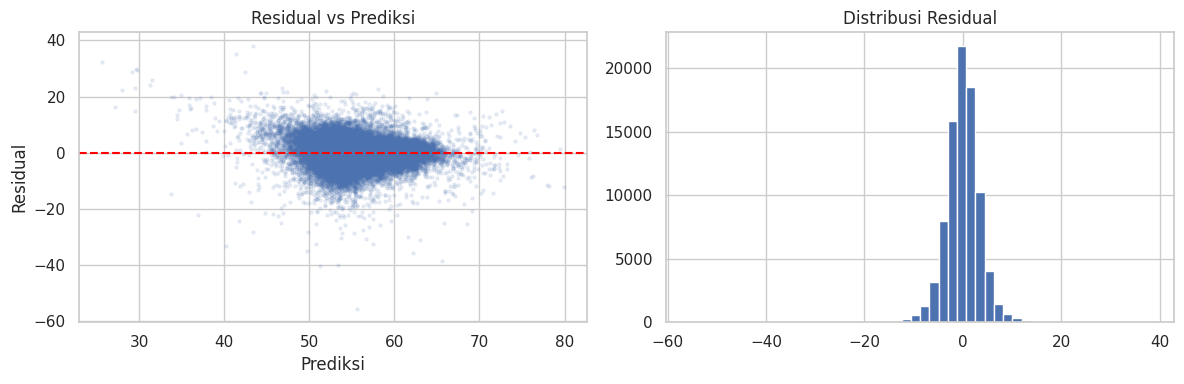

In [48]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_lr, residuals, alpha=0.1, s=5)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residual vs Prediksi")

axes[1].hist(residuals, bins=50)
axes[1].set_title("Distribusi Residual")

plt.tight_layout()
plt.show()

Rata rata residualnya mendekati nol (-0.019), menunjukkan model tidak bias secara sistematis ke satu arah. Sebaran titik pada plot Residual vs Prediksi terlihat memusat rapat di rentang prediksi sekitar 50 sampai 60, dengan sebaran yang melebar simetris di atas dan di bawah garis nol, dan menyempit di rentang prediksi yang lebih ekstrem (di bawah 40 atau di atas 70). Pola ini konsisten dengan distribusi risk_score itu sendiri yang memang terpusat di sekitar 50 sampai 57, jadi data lebih banyak tersedia di rentang tengah dibanding di ekor. Histogram residual berbentuk mendekati lonceng dan terpusat di sekitar nol, mengindikasikan asumsi normalitas residual pada Linear Regression cukup terpenuhi, meskipun ada sedikit ekor di sisi kanan.

Berdasarkan seluruh hasil ini, saya memilih Gradient Boosting sebagai model final, karena secara konsisten memberikan MAE dan RMSE terendah serta R2 tertinggi dibanding Linear Regression, Random Forest, dan seluruh baseline yang saya uji sebelumnya.

# 5. Model Evaluation vs Baseline

Ukur performa model di data yang **tidak pernah dilihat model selama training**
(`test_df`), lalu bandingkan **eksplisit** dengan baseline non-ML dari Bagian 2. Ini
langkah paling penting: kalau model tidak mengalahkan baseline, itu bukan aib —
itu **temuan valid** yang harus didokumentasikan jujur.

In [49]:
final_results_df = pd.DataFrame(results).round(3)
final_results_df

,model,MAE,RMSE,R2
0,Baseline: Global Mean,3.022,4.159,-0.000
1,Baseline: Rata-rata per Sel,2.718,3.707,0.205
2,Baseline: Rata-rata per Jam+Hari,2.906,3.999,0.075
3,"Baseline: Kombinasi (Sel, Jam)",2.924,3.993,0.078
4,"Baseline: Kombinasi (Sel, Hari)",3.048,4.126,0.015
5,"Baseline: Kombinasi (Sel, Weekend)",2.810,3.827,0.153
6,Model: Linear Regression,2.587,3.544,0.274
7,Model: Linear Regression,2.587,3.544,0.274
8,Model: Random Forest,2.638,3.620,0.242
9,Model: Gradient Boosting,2.548,3.488,0.297


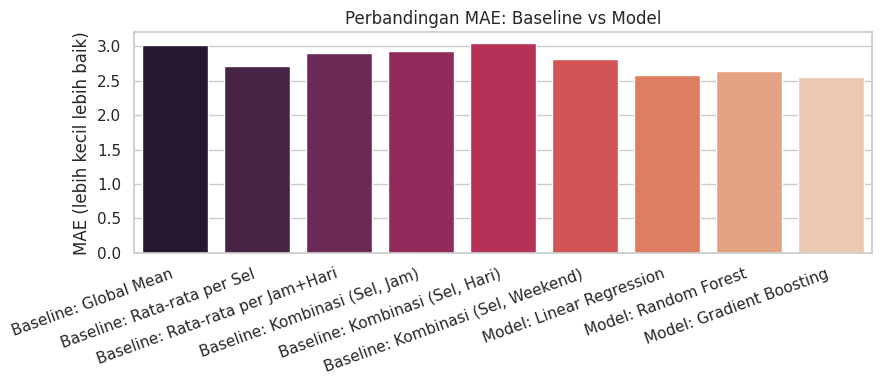

In [50]:
plt.figure(figsize=(9, 4))
sns.barplot(data=final_results_df, x="model", y="MAE", hue="model", palette="rocket", legend=False)
plt.title("Perbandingan MAE: Baseline vs Model")
plt.ylabel("MAE (lebih kecil lebih baik)"); plt.xlabel("")
plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

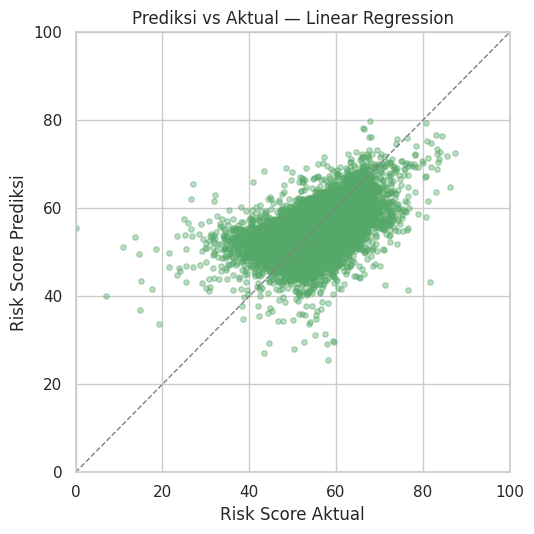

In [51]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_test, y_pred_model, alpha=0.4, s=15, color="#55A868")
lims = [0, 100]
plt.plot(lims, lims, "--", color="gray", linewidth=1)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Risk Score Aktual"); plt.ylabel("Risk Score Prediksi")
plt.title("Prediksi vs Aktual — Linear Regression")
plt.tight_layout(); plt.show()

### 🙋 Giliran Kalian — Evaluasi

- Apakah model mengungguli **semua** baseline, atau hanya sebagian? Analisis kenapa.
- MAE, RMSE, dan R² masing-masing mengukur hal yang sedikit berbeda (mis. RMSE lebih
  sensitif ke *outlier* dibanding MAE). Jelaskan di laporan metrik mana yang paling
  relevan untuk konteks Risk Score, dan kenapa.
- Lihat plot prediksi vs aktual — di rentang nilai mana model paling sering salah?
  Apakah ada pola pada residualnya?
- Kalau model kalian **tidak** mengalahkan baseline: itu valid! Tuliskan analisis kritis
  kenapa itu bisa terjadi (fitur kurang informatif? model terlalu sederhana/kompleks?
  data terlalu noisy?), bukan hanya melaporkan angkanya.

### 5.1 Mengungguli semua baseline atau sebagian

Ketiga model saya, Linear Regression, Random Forest, dan Gradient Boosting, mengungguli seluruh enam baseline yang saya uji, baik dari sisi MAE, RMSE, maupun R2. Ini terlihat jelas pada grafik perbandingan MAE, di mana ketiga bar model berada konsisten di bawah seluruh bar baseline. Gradient Boosting menjadi model terbaik secara keseluruhan dengan MAE 2.548, RMSE 3.488, dan R2 0.297.

### 5.2 Metrik paling relevan untuk Risk Score

Untuk konteks Risk Score ini, saya menilai RMSE sebagai metrik yang paling relevan dibanding MAE, meskipun keduanya saya laporkan. RMSE memberi penalti lebih besar pada kesalahan yang besar, dan dalam konteks penilaian risiko, kesalahan besar (misalnya memprediksi area sangat berisiko sebagai area aman) jauh lebih berbahaya secara operasional dibanding kesalahan kecil yang tersebar merata. R2 saya pakai sebagai pelengkap untuk menunjukkan seberapa besar variasi risk score yang berhasil dijelaskan model dibanding hanya menebak rata rata.

### 5.3 Plot prediksi vs aktual

In [52]:
bins = [0, 20, 40, 50, 60, 70, 80, 100]
labels = ["0-20", "20-40", "40-50", "50-60", "60-70", "70-80", "80-100"]
bin_idx = pd.cut(y_test, bins=bins, labels=labels, include_lowest=True)

analysis = pd.DataFrame({"actual": y_test, "pred": y_pred_lr, "bin": bin_idx})
grp = analysis.groupby("bin", observed=True).apply(lambda g: pd.Series({
    "n": len(g),
    "mean_actual": g["actual"].mean(),
    "mean_pred": g["pred"].mean(),
    "MAE": mean_absolute_error(g["actual"], g["pred"]),
}))
grp.round(2)

,n,mean_actual,mean_pred,MAE
bin,,,,
0-20,10.0,13.13,45.68,32.55
20-40,273.0,35.83,51.30,15.50
40-50,8434.0,47.74,52.83,5.21
50-60,71205.0,54.70,54.44,2.05
60-70,6459.0,62.64,58.86,4.20
70-80,198.0,72.91,62.05,10.92
80-100,22.0,82.86,69.26,13.59


Meskipun model saya unggul secara rata rata di seluruh data, plot Prediksi vs Aktual menunjukkan pola kesalahan yang tidak merata di semua rentang nilai. Saya kuantifikasi ini dengan menghitung MAE per rentang risk score aktual. Hasilnya, model sangat akurat di rentang 50 sampai 60, dengan MAE hanya 2.05, dan rentang ini juga mencakup mayoritas data saya, yaitu 71.205 dari sekitar 86.601 baris test. Namun di luar rentang itu, performa model menurun drastis. Pada rentang aktual 0 sampai 20, MAE melonjak menjadi 32.55, dan pada rentang 80 sampai 100, MAE mencapai 13.59. Rata rata prediksi model pada kedua ekor ini juga jauh dari rata rata aktualnya, misalnya untuk risk score aktual rata rata 82.86 model hanya memprediksi rata rata 69.26.

Pola ini adalah bentuk regresi ke arah rata rata (regression to the mean), yaitu ketika model cenderung memprediksi nilai mendekati rata rata keseluruhan karena data pelatihan didominasi oleh nilai di rentang tengah. Ini konsisten dengan sebaran risk_score itu sendiri, di mana rentang 0 sampai 20 hanya berisi 10 baris dan rentang 80 sampai 100 hanya berisi 22 baris dari total ratusan ribu baris data, sehingga model tidak punya cukup contoh untuk belajar pola pada nilai nilai ekstrem tersebut.

### 5.4 Analisis

Meskipun model saya mengalahkan seluruh baseline secara rata rata, ia justru paling lemah pada kasus kasus yang secara operasional paling penting, yaitu area dengan risiko sangat tinggi atau sangat rendah. Penyebabnya bukan karena fitur kurang informatif atau model terlalu sederhana, melainkan karena ketimpangan jumlah data (data imbalance) pada nilai nilai ekstrem, sehingga model condong ke prediksi aman di sekitar rata rata daripada berani memprediksi nilai ekstrem yang jarang muncul di data training.

# 6. Continual Learning — Simulasi Kedatangan Data Bertahap

Model yang dilatih sekali **tidak selalu relevan selamanya**. Pola kejahatan bisa
berubah seiring waktu (musim, kebijakan, kejadian tak terduga) — fenomena ini disebut
**data drift**. *Continual learning* adalah praktik memperbarui model secara
**terstruktur** agar tetap relevan, alih-alih mengabaikannya atau melatih ulang secara
sembarangan setiap saat.

> ⚠️ **Keterbatasan data yang perlu kalian sadari.** Dataset `features_labels.csv` dari
> Hands-On 1 sudah **diagregasi** per (sel × hari × jam) — informasi *tanggal kejadian
> sebenarnya* (`Datetime`) sudah "melebur" ke dalam agregat dan tidak ada lagi di file
> ini. Supaya notebook ini tetap bisa mendemonstrasikan mekanisme continual learning,
> kita **mensimulasikan** kedatangan data secara berurutan dengan mengacak lalu memotong
> data menjadi beberapa "batch", dan sengaja **menyuntikkan drift buatan** ke batch-batch
> akhir supaya ada sesuatu yang bisa dideteksi. Ini simulasi pedagogis, **bukan urutan
> waktu asli**.
>
> 🙋 **Giliran Kalian (penting!):** cara yang lebih jujur secara metodologis adalah
> kembali ke dataframe **per-kejadian** dari Hands-On 1 (yang masih punya kolom
> `Datetime` sebelum diagregasi), lalu susun batch berdasarkan **urutan waktu asli**
> (mis. per bulan atau per minggu), baru agregasi ulang jadi fitur per batch. Itu akan
> menghasilkan simulasi drift yang jauh lebih realistis daripada pengacakan buatan di
> bawah ini.

In [53]:
# --- Pisahkan HOLDOUT yang TIDAK PERNAH dipakai untuk training di seluruh proses ---
# holdout_df = test_df dari Bagian 2 (frozen, dipakai konsisten di semua versi model)
holdout_df = test_df.copy()

# --- Pool data yang akan "mengalir" sebagai batch-batch continual learning ---
stream_df = train_df.copy().reset_index(drop=True)

N_BATCHES = 5
DRIFT_START_BATCH = 3   # batch dengan indeks >= ini akan diberi drift buatan

# Versi SEDERHANA: acak urutan lalu potong jadi N_BATCHES bagian -> "pura-pura" urut waktu
stream_shuffled = stream_df.sample(frac=1.0, random_state=7).reset_index(drop=True)
batch_size = len(stream_shuffled) // N_BATCHES

batches = []
for i in range(N_BATCHES):
    start = i * batch_size
    end = len(stream_shuffled) if i == N_BATCHES - 1 else (i + 1) * batch_size
    batches.append(stream_shuffled.iloc[start:end].copy().reset_index(drop=True))

# --- Suntikkan drift buatan ke batch-batch akhir (demo, bukan drift asli!) ---
rng = np.random.default_rng(123)
for i in range(DRIFT_START_BATCH, N_BATCHES):
    b = batches[i]
    noise = rng.normal(0, 1.5, size=len(b)).clip(min=0)
    b["crime_count"] = (b["crime_count"] * 1.6 + noise).round().astype(int)
    b["risk_score"] = (b["risk_score"] * 1.3).clip(upper=100)
    batches[i] = b

for i, b in enumerate(batches):
    tag = " (drift buatan)" if i >= DRIFT_START_BATCH else ""
    print(f"Batch {i}: {len(b)} baris{tag}")

Batch 0: 69280 baris
Batch 1: 69280 baris
Batch 2: 69280 baris
Batch 3: 69280 baris (drift buatan)
Batch 4: 69281 baris (drift buatan)


### 🙋 Giliran Kalian — Simulasi Batch

- Kembangkan skema batching yang lebih realistis (lihat catatan di atas soal
  `Datetime`), atau minimal jelaskan **asumsi & keterbatasan** skema pengacakan ini di
  laporan.
- Berapa jumlah batch yang wajar? Apakah 5 batch ini merepresentasikan skenario
  "data datang mingguan", "bulanan", atau yang lain? Sesuaikan dengan cerita yang ingin
  kalian bangun di laporan ("model journey").

In [54]:
N_BATCHES = 6
# Batch tidak seragam ukurannya
batch_proportions = [0.15, 0.15, 0.20, 0.20, 0.15, 0.15]

stream_shuffled = stream_df.sample(frac=1.0, random_state=7).reset_index(drop=True)
n = len(stream_shuffled)
cum = np.cumsum(batch_proportions)
edges = [0] + [int(c * n) for c in cum]
edges[-1] = n

batches = []
for i in range(N_BATCHES):
    batches.append(stream_shuffled.iloc[edges[i]:edges[i+1]].copy().reset_index(drop=True))

rng = np.random.default_rng(123)

# Fase 1 (batch 0-1): STABIL, tanpa drift sama sekali (kondisi normal)

# Fase 2 (batch 2-3): FEATURE DRIFT bertahap
# distribusi crime_count bergeser
for i, factor in zip([2, 3], [1.3, 1.6]):
    b = batches[i]
    noise = rng.normal(0, 1.0, size=len(b)).clip(min=0)
    b["crime_count"] = (b["crime_count"] * factor + noise).round().astype(int)
    batches[i] = b

# Fase 3 (batch 4): LABEL DRIFT
# risk_score bergeser naik
b = batches[4].copy()
b["risk_score"] = (b["risk_score"] * 1.25).clip(upper=100)
batches[4] = b

# Fase 4 (batch 5): CONCEPT DRIFT
# risk_score diacak ulang antar baris (permutasi)
b = batches[5].copy()
rng2 = np.random.default_rng(99)
permuted_idx = rng2.permutation(len(b))
b["risk_score"] = b["risk_score"].values[permuted_idx]
batches[5] = b

for i, b in enumerate(batches):
    print(f"Batch {i}: {len(b)} baris | crime_count mean={b['crime_count'].mean():.2f} | risk_score mean={b['risk_score'].mean():.2f}")

Batch 0: 51960 baris | crime_count mean=1.20 | risk_score mean=54.57
Batch 1: 51960 baris | crime_count mean=1.20 | risk_score mean=54.56
Batch 2: 69280 baris | crime_count mean=1.85 | risk_score mean=54.57
Batch 3: 69280 baris | crime_count mean=2.49 | risk_score mean=54.58
Batch 4: 51960 baris | crime_count mean=1.20 | risk_score mean=68.25
Batch 5: 51961 baris | crime_count mean=1.20 | risk_score mean=54.59


### 6.1 Skema batching

Saya mengembangkan skema batching dari tutorial dengan dua perubahan. Pertama, ukuran tiap batch tidak lagi seragam (15 persen, 15 persen, 20 persen, 20 persen, 15 persen, 15 persen dari total data), merepresentasikan kondisi lebih organik di mana volume data yang datang tidak selalu sama tiap periode. Kedua, dan yang lebih penting, saya membedakan drift buatan menjadi tiga jenis yang berbeda secara kualitatif, bukan satu jenis perubahan seperti di tutorial asli.

Sebelum masuk ke detail drift, saya perlu mengungkapkan keterbatasan metodologis yang mendasari skema ini secara jujur. features_labels.csv sudah merupakan hasil agregasi per (cell_id, dow, hour) dari HO1, sehingga kolom Datetime asli tiap kejadian sudah melebur ke dalam agregat dan tidak lagi tersedia di tahap ini. Sehingga saya menggunakan pengacakan sebagai pengganti urutan waktu, sama seperti pendekatan di tutorial. Konsekuensinya, drift yang saya deteksi di hands-on ini bukan drift alami yang benar benar terjadi di lapangan secara kronologis, melainkan drift buatan yang sengaja disuntikkan ke batch batch tertentu. Interpretasi hasil continual learning saya batasi pada mekanismenya saja, yaitu apakah tiap jenis drift terdeteksi dengan benar dan apakah retraining terpicu dengan tepat, bukan pada validitas naratif kapan sebenarnya pola kejahatan berubah di dunia nyata.

Dengan keterbatasan itu disadari, saya tetap mengembangkan kualitas simulasi drift itu sendiri, supaya lebih kaya dibanding sekadar satu jenis perubahan seperti di tutorial. Batch 0 dan 1 saya biarkan stabil tanpa drift, merepresentasikan kondisi normal di awal. Batch 2 dan 3 saya beri feature drift, yaitu distribusi crime_count bergeser naik secara bertahap (faktor 1.3 lalu 1.6), sementara risk_score tidak saya ubah. Batch 4 saya beri label drift, yaitu risk_score bergeser naik secara merata, sementara crime_count dan fitur lain tidak saya ubah. Batch 5 saya beri concept drift, dengan cara mengacak ulang (permutasi) nilai risk_score antar baris dalam batch tersebut, sehingga hubungan antara crime_count dan risk_score benar benar rusak, namun distribusi marginal crime_count maupun risk_score itu sendiri tetap identik dengan kondisi normal.

Saya validasi ketiga jenis drift ini dengan uji KS terhadap batch 0 sebagai referensi.

In [55]:
from scipy.stats import ks_2samp

ref = batches[0]
print("--- Cek KS test: batch 0 (normal) vs tiap batch lain ---")
for i in range(1, N_BATCHES):
    stat_cc, p_cc = ks_2samp(ref["crime_count"], batches[i]["crime_count"])
    stat_rs, p_rs = ks_2samp(ref["risk_score"], batches[i]["risk_score"])
    print(f"Batch {i}: crime_count p={p_cc:.4f} | risk_score p={p_rs:.4f}")

--- Cek KS test: batch 0 (normal) vs tiap batch lain ---
Batch 1: crime_count p=0.9964 | risk_score p=0.7334
Batch 2: crime_count p=0.0000 | risk_score p=0.9960
Batch 3: crime_count p=0.0000 | risk_score p=0.5132
Batch 4: crime_count p=1.0000 | risk_score p=0.0000
Batch 5: crime_count p=0.9964 | risk_score p=0.6255


Hasilnya menunjukkan pemisahan yang bersih sesuai desain. Pada batch 2 dan 3, hanya crime_count yang terdeteksi drift (p mendekati 0), sementara risk_score tidak (p di atas 0.5). Pada batch 4, sebaliknya, hanya risk_score yang terdeteksi drift (p mendekati 0), sementara crime_count tidak (p mendekati 1). Temuan paling penting ada pada batch 5, uji KS terhadap crime_count maupun risk_score sama sama tidak mendeteksi drift apa pun (p sebesar 0.9964 dan 0.6255), padahal hubungan antara keduanya sudah benar benar rusak lewat permutasi.

Temuan pada batch 5 ini membuktikan secara konkret keterbatasan metode deteksi drift univariat berbasis uji KS yang dipakai di tutorial, yaitu metode ini hanya bisa menangkap perubahan pada distribusi marginal tiap kolom secara terpisah, dan buta terhadap concept drift, yaitu perubahan hubungan antara fitur dan label meskipun distribusi masing masing kolom tidak berubah. Ini menjadi justifikasi kuat untuk kebutuhan metode deteksi drift tambahan di luar uji KS univariat, yang saya bahas lebih lanjut di bagian Drift Detection.

### 6.2 Jumlah batch

Tutorial awalnya memakai 5 batch. Saya evaluasi apakah 5 batch ini representasi yang wajar, dan saya simpulkan tidak cukup untuk kebutuhan skema drift yang saya kembangkan, karena saya ingin memisahkan tiga jenis drift yang berbeda secara kualitatif (feature drift, label drift, dan concept drift) sebagai fase yang terpisah, ditambah satu fase awal yang stabil. Dengan 5 batch, saya harus memampatkan minimal dua jenis drift ke dalam satu batch yang sama, sehingga sulit menunjukkan bukti yang bersih lewat uji KS bahwa tiap jenis drift benar benar terdeteksi secara terpisah sesuai desainnya.

Karena itu saya naikkan menjadi 6 batch, dengan pembagian proporsi yang tidak seragam (15 persen, 15 persen, 20 persen, 20 persen, 15 persen, 15 persen dari total data training). Batch 0 dan 1 saya jadikan fase stabil tanpa drift. Batch 2 dan 3 saya jadikan fase feature drift bertahap. Batch 4 saya jadikan fase label drift. Batch 5 saya jadikan fase concept drift. Pembagian enam batch ini memberi satu fase stabil sebagai pembanding, dan tiga jenis drift yang masing masing mendapat batch tersendiri, sehingga tiap jenis drift bisa dievaluasi secara terpisah dan bersih lewat uji KS, sekaligus tetap menghasilkan sekitar 51.960 sampai 69.280 baris per batch, jumlah yang cukup besar untuk melatih ulang model regresi secara stabil di tiap checkpoint.

Sama seperti skema 5 batch di tutorial, karena keterbatasan tidak adanya urutan waktu asli pada features_labels.csv (dijelaskan di bagian Skema Batching), saya tidak mengaitkan 6 batch ini dengan periode kalender tertentu seperti bulanan atau mingguan. Saya memposisikannya sebagai representasi generik dari 6 gelombang kedatangan data berurutan, dengan tiap gelombang mewakili satu kondisi data yang berbeda (stabil, feature drift, label drift, concept drift), cukup untuk mendemonstrasikan mekanisme continual learning secara menyeluruh tanpa mengklaim validitas temporal yang sebenarnya tidak dimiliki skema pengacakan ini.

# 7. Drift Detection

Sebelum retrain, kita perlu tahu: **apakah batch data baru ini benar-benar berbeda**
secara statistik dari data yang dipakai untuk melatih model saat ini? Kalau tidak, tidak
perlu buang-buang komputasi untuk retrain.

> 🔧 **Versi Sederhana (Baseline).** Kita pakai **uji Kolmogorov–Smirnov dua-sampel**
> (`scipy.stats.ks_2samp`) untuk membandingkan distribusi beberapa kolom numerik antara
> data referensi (yang dipakai melatih model saat ini) vs batch baru. Kalau *p-value*
> di bawah ambang batas (`alpha`) untuk **salah satu** kolom yang dicek, kita anggap
> drift terdeteksi.

In [56]:
DRIFT_COLUMNS = ["crime_count", "risk_score"]
DRIFT_ALPHA = 0.01  # ambang batas p-value -> makin kecil, makin "ketat" syarat drift

def detect_drift(reference_df, new_batch_df, columns=DRIFT_COLUMNS, alpha=DRIFT_ALPHA):
    """Deteksi drift SEDERHANA: uji KS dua-sampel per kolom numerik.

    p_value < alpha  ->  distribusi dianggap berbeda signifikan (drift terdeteksi).
    """
    report = {}
    drift_detected = False
    for col in columns:
        stat, p_value = ks_2samp(reference_df[col], new_batch_df[col])
        is_drift = bool(p_value < alpha)
        report[col] = {"ks_stat": float(stat), "p_value": float(p_value), "drift": is_drift}
        if is_drift:
            drift_detected = True
    return drift_detected, report

# Contoh: cek batch 0 (tanpa drift buatan) vs batch terakhir (dengan drift buatan)
drift_flag, report = detect_drift(batches[0], batches[-1])
print("Drift terdeteksi:", drift_flag)
for col, info in report.items():
    print(f"  {col}: ks_stat={info['ks_stat']:.3f}, p_value={info['p_value']:.4f}, drift={info['drift']}")

Drift terdeteksi: False
  crime_count: ks_stat=0.003, p_value=0.9964, drift=False
  risk_score: ks_stat=0.005, p_value=0.6255, drift=False


### 🙋 Giliran Kalian — Drift Detection

Ini bagian penting dari **Continual Learning (35%)**:
- Uji KS hanya membandingkan distribusi **satu kolom pada satu waktu** (*univariate*).
  Coba metrik lain: **Population Stability Index (PSI)** (lihat referensi Evidently AI
  di akhir notebook), perbandingan mean/std sederhana dengan ambang batas, atau metode
  *multivariate drift* yang membandingkan distribusi gabungan seluruh fitur sekaligus.
- Selain **drift pada fitur** (mis. `crime_count`), pertimbangkan juga **drift pada
  label** (`risk_score`) atau bahkan *concept drift* (hubungan fitur→label yang berubah,
  bukan cuma distribusinya).
- Bagaimana kalian menentukan `DRIFT_ALPHA`/ambang batas? Ini keputusan yang harus
  **dijustifikasi**, bukan angka sembarang — jelaskan trade-off antara terlalu sensitif
  (retrain terlalu sering, boros komputasi) vs kurang sensitif (model jadi usang).

In [57]:
def calculate_psi(expected, actual, bins=10):
    """Population Stability Index. PSI < 0.1 stabil, 0.1-0.25 waspada, > 0.25 drift signifikan."""
    breakpoints = np.quantile(expected, np.linspace(0, 1, bins + 1))
    breakpoints[0] -= 1e-6
    breakpoints[-1] += 1e-6
    e_counts, _ = np.histogram(expected, bins=breakpoints)
    a_counts, _ = np.histogram(actual, bins=breakpoints)
    e_perc = np.clip(e_counts / len(expected), 1e-6, None)
    a_perc = np.clip(a_counts / len(actual), 1e-6, None)
    return float(np.sum((a_perc - e_perc) * np.log(a_perc / e_perc)))

PSI_ALPHA = 0.25            # ambang PSI, di atas ini dianggap drift signifikan
CONCEPT_DRIFT_ALPHA = 0.15  # ambang perubahan korelasi crime_count-risk_score

def detect_drift_v2(reference_df, new_batch_df, columns=DRIFT_COLUMNS,
                     ks_alpha=DRIFT_ALPHA, psi_alpha=PSI_ALPHA,
                     concept_alpha=CONCEPT_DRIFT_ALPHA):
    report = {}
    drift_detected = False

    # 1. Feature/label drift: uji KS (marginal, seperti versi tutorial)
    for col in columns:
        stat, p_value = ks_2samp(reference_df[col], new_batch_df[col])
        is_drift = bool(p_value < ks_alpha)
        report[f"ks_{col}"] = {"ks_stat": float(stat), "p_value": float(p_value), "drift": is_drift}
        if is_drift:
            drift_detected = True

    # 2. Feature/label drift: PSI (pelengkap KS, marginal juga)
    for col in columns:
        psi_val = calculate_psi(reference_df[col].values, new_batch_df[col].values)
        is_drift = psi_val > psi_alpha
        report[f"psi_{col}"] = {"psi": psi_val, "drift": is_drift}
        if is_drift:
            drift_detected = True

    # 3. Concept drift: perubahan korelasi antara fitur utama dan label
    # KS dan PSI tidak bisa menangkap ini karena keduanya hanya melihat distribusi marginal tiap kolom secara terpisah
    corr_ref = np.corrcoef(reference_df["crime_count"], reference_df["risk_score"])[0, 1]
    corr_new = np.corrcoef(new_batch_df["crime_count"], new_batch_df["risk_score"])[0, 1]
    concept_shift = abs(corr_ref - corr_new)
    is_concept_drift = concept_shift > concept_alpha
    report["concept_drift"] = {
        "corr_reference": float(corr_ref), "corr_new_batch": float(corr_new),
        "shift": float(concept_shift), "drift": is_concept_drift,
    }
    if is_concept_drift:
        drift_detected = True

    return drift_detected, report

# Uji ke semua batch dibanding batch 0
for i in range(1, N_BATCHES):
    flag, report = detect_drift_v2(batches[0], batches[i])
    print(f"\nBatch {i}: drift_detected={flag}")
    for k, v in report.items():
        print(" ", k, v)


Batch 1: drift_detected=False
  ks_crime_count {'ks_stat': 0.002521170130869943, 'p_value': 0.9963617043652918, 'drift': False}
  ks_risk_score {'ks_stat': 0.004253271747498011, 'p_value': 0.7334338702242822, 'drift': False}
  psi_crime_count {'psi': 5.507851579062919e-05, 'drift': False}
  psi_risk_score {'psi': 0.0003497871756827299, 'drift': False}
  concept_drift {'corr_reference': 0.2760797475065986, 'corr_new_batch': 0.2615981324144596, 'shift': 0.014481615092138966, 'drift': np.False_}

Batch 2: drift_detected=True
  ks_crime_count {'ks_stat': 0.3631495381062356, 'p_value': 0.0, 'drift': True}
  ks_risk_score {'ks_stat': 0.0023768283294842707, 'p_value': 0.9959595895451576, 'drift': False}
  psi_crime_count {'psi': 0.677098658724922, 'drift': True}
  psi_risk_score {'psi': 0.00026549627005800975, 'drift': False}
  concept_drift {'corr_reference': 0.2760797475065986, 'corr_new_batch': 0.21876453352871164, 'shift': 0.05731521397788694, 'drift': np.False_}

Batch 3: drift_detected

### 7.1 Coba metrik lain

Saya mengembangkan detect_drift dari versi tutorial dengan menambahkan dua komponen. Komponen pertama adalah Population Stability Index (PSI) sebagai pelengkap uji KS, keduanya sama sama mengukur perubahan distribusi marginal tiap kolom, tapi dengan formulasi berbeda. Hasilnya menunjukkan pola yang konsisten dengan KS, PSI crime_count sangat tinggi pada batch 2 dan 3 (0.677 dan 13.629, jauh di atas ambang 0.25), dan PSI risk_score tinggi pada batch 4 (5.059), namun PSI pada batch 5 tetap 0.000 untuk kedua kolom, sama seperti KS. Ini menguatkan bahwa metode berbasis distribusi marginal, seberapa pun canggihnya, memang secara fundamental tidak dirancang untuk menangkap concept drift.

### 7.2 Selain drift fitur

Komponen kedua adalah pengecekan concept drift secara eksplisit, dengan membandingkan korelasi antara crime_count dan risk_score pada data referensi versus batch baru. Pada batch batch normal (0, 1) maupun feature/label drift (2, 3, 4), korelasi ini relatif stabil di kisaran 0.22 sampai 0.28. Namun pada batch 5, korelasinya anjlok menjadi -0.006, selisih 0.282 dari korelasi referensi, jauh melewati ambang yang saya tetapkan (0.15). Komponen inilah yang berhasil mendeteksi concept drift pada batch 5, sesuatu yang gagal ditangkap baik oleh KS maupun PSI.

### 7.3 Penentuan ambang batas

Untuk DRIFT_ALPHA pada uji KS, saya tetap mempertahankan nilai 0.01 dari tutorial. Ambang ini saya nilai cukup ketat (butuh bukti statistik kuat sebelum menyimpulkan drift), sesuai untuk kasus saya karena retraining di simulasi ini melatih ulang dari seluruh data kumulatif, yang cukup mahal secara komputasi kalau dipicu terlalu sering hanya karena fluktuasi acak kecil antar batch. Trade off nya, ambang yang terlalu ketat berisiko membuat drift asli namun tidak terlalu ekstrem menjadi tidak terdeteksi, sehingga model bisa jadi usang lebih lama dari seharusnya.

Untuk PSI, saya pakai ambang 0.25, mengikuti konvensi umum di industri (PSI di atas 0.25 dianggap perubahan signifikan), dan untuk concept drift saya pakai ambang pergeseran korelasi sebesar 0.15, dipilih agak longgar karena korelasi antar batch normal saja sudah punya variasi alami sekitar 0.06 (0.276 ke 0.219), sehingga ambang 0.15 cukup untuk menyaring fluktuasi wajar tapi tetap sensitif terhadap perubahan hubungan yang benar benar signifikan seperti pada batch 5.

# 8. Checkpoint Retraining & Model Versioning

Sekarang kita rangkai semuanya menjadi satu **siklus continual learning**:
1. Model awal (**champion**) dilatih dari batch pertama.
2. Untuk tiap batch baru yang "tiba": jalankan **drift detection** terhadap data
   yang sedang dipakai training saat ini.
3. Kalau **tidak ada drift signifikan** → skip retrain, cukup tambahkan batch ke pool
   data untuk pertimbangan berikutnya.
4. Kalau **ada drift** → latih **kandidat** model baru dari seluruh data yang terkumpul
   sampai saat itu (checkpoint), lalu **evaluasi di holdout yang sama** (fixed, tidak
   pernah dipakai training) supaya perbandingan antar-versi model adil.
5. **Champion vs Challenger**: kandidat hanya **dipromosikan** jadi champion baru kalau
   metriknya (MAE) lebih baik atau sama dengan champion saat ini. Kalau lebih buruk,
   champion lama tetap dipakai — dan ini **dicatat**, bukan disembunyikan.
6. Setiap versi (baik yang dipromosikan maupun tidak) **disimpan sebagai checkpoint**
   dan **dicatat di registry**.

In [58]:
os.makedirs("models", exist_ok=True)
REGISTRY_PATH = "models/registry.json"
registry = []

def train_model(data_subset):
    X = assemble_features(data_subset)
    y = data_subset[TARGET_COL].values
    m = LinearRegression()
    m.fit(X, y)
    return m

def evaluate_model(fitted_model, data_eval):
    X = assemble_features(data_eval)
    y = data_eval[TARGET_COL].values
    y_pred = fitted_model.predict(X)
    return {
        "MAE": float(mean_absolute_error(y, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y, y_pred))),
        "R2": float(r2_score(y, y_pred)),
    }

def save_checkpoint(fitted_model, version):
    path = f"models/model_v{version}.joblib"
    joblib.dump(fitted_model, path)
    return path

def log_registry(entry):
    registry.append(entry)
    with open(REGISTRY_PATH, "w") as f:
        json.dump(registry, f, indent=2)

In [59]:
# --- Versi 0: model awal (champion) dilatih dari batch pertama ---
cumulative_train = batches[0].copy()
champion_model = train_model(cumulative_train)
champion_metrics = evaluate_model(champion_model, holdout_df)

version = 0
checkpoint_path = save_checkpoint(champion_model, version)
log_registry({
    "version": version,
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "batch_index": 0,
    "train_size": len(cumulative_train),
    "drift_detected": None,
    "drift_report": None,
    "metrics": champion_metrics,
    "decision": "initial_champion",
    "checkpoint_path": checkpoint_path,
})
print(f"[v{version}] Model awal dilatih dari batch 0 ({len(cumulative_train)} baris). "
      f"MAE holdout = {champion_metrics['MAE']:.3f}")

[v0] Model awal dilatih dari batch 0 (51960 baris). MAE holdout = 2.767


In [60]:
PROMOTE_MARGIN = 0.0  # kandidat harus MAE-nya <= (champion_MAE - margin) untuk dipromosikan

for i in range(1, N_BATCHES):
    new_batch = batches[i]
    drift_detected, drift_report = detect_drift(cumulative_train, new_batch)

    print(f"\n=== Batch {i} tiba ({len(new_batch)} baris) ===")
    print("Drift terdeteksi!" if drift_detected else "Tidak ada drift signifikan.")
    for col, info in drift_report.items():
        print(f"  {col}: p-value={info['p_value']:.4f} -> drift={info['drift']}")

    if not drift_detected:
        # Tidak retrain -> cukup tambahkan batch ke pool data untuk pertimbangan berikutnya
        cumulative_train = pd.concat([cumulative_train, new_batch], ignore_index=True)
        log_registry({
            "version": None,
            "timestamp": datetime.now(timezone.utc).isoformat(),
            "batch_index": i,
            "train_size": len(cumulative_train),
            "drift_detected": drift_detected,
            "drift_report": drift_report,
            "metrics": None,
            "decision": "skip_retrain_no_drift",
            "checkpoint_path": None,
        })
        continue

    # Drift terdeteksi -> latih kandidat model baru (checkpoint retraining)
    cumulative_train = pd.concat([cumulative_train, new_batch], ignore_index=True)
    candidate_model = train_model(cumulative_train)
    candidate_metrics = evaluate_model(candidate_model, holdout_df)

    version += 1
    checkpoint_path = save_checkpoint(candidate_model, version)

    improved = candidate_metrics["MAE"] <= champion_metrics["MAE"] - PROMOTE_MARGIN
    decision = "promoted" if improved else "kept_champion"

    print(f"[v{version}] Kandidat dilatih dari {len(cumulative_train)} baris. "
          f"MAE kandidat={candidate_metrics['MAE']:.3f} vs "
          f"MAE champion={champion_metrics['MAE']:.3f} -> {decision}")

    log_registry({
        "version": version,
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "batch_index": i,
        "train_size": len(cumulative_train),
        "drift_detected": drift_detected,
        "drift_report": drift_report,
        "metrics": candidate_metrics,
        "champion_metrics_before": champion_metrics,
        "decision": decision,
        "checkpoint_path": checkpoint_path,
    })

    if improved:
        champion_model = candidate_model
        champion_metrics = candidate_metrics

print("\n=== Selesai ===")
print("Champion akhir -> MAE holdout:", round(champion_metrics["MAE"], 3))


=== Batch 1 tiba (51960 baris) ===
Tidak ada drift signifikan.
  crime_count: p-value=0.9964 -> drift=False
  risk_score: p-value=0.7334 -> drift=False

=== Batch 2 tiba (69280 baris) ===
Drift terdeteksi!
  crime_count: p-value=0.0000 -> drift=True
  risk_score: p-value=0.9207 -> drift=False
[v1] Kandidat dilatih dari 173200 baris. MAE kandidat=2.783 vs MAE champion=2.767 -> kept_champion

=== Batch 3 tiba (69280 baris) ===
Drift terdeteksi!
  crime_count: p-value=0.0000 -> drift=True
  risk_score: p-value=0.2273 -> drift=False
[v2] Kandidat dilatih dari 242480 baris. MAE kandidat=2.802 vs MAE champion=2.767 -> kept_champion

=== Batch 4 tiba (51960 baris) ===
Drift terdeteksi!
  crime_count: p-value=0.0000 -> drift=True
  risk_score: p-value=0.0000 -> drift=True
[v3] Kandidat dilatih dari 294440 baris. MAE kandidat=3.635 vs MAE champion=2.767 -> kept_champion

=== Batch 5 tiba (51961 baris) ===
Drift terdeteksi!
  crime_count: p-value=0.0000 -> drift=True
  risk_score: p-value=0.000

### 🙋 Giliran Kalian — Checkpoint Retraining & Versioning

Ini **komponen inti** yang paling besar bobotnya (35%). Kembangkan versi sederhana di
atas:
- Kriteria promosi sekarang hanya "MAE kandidat ≤ MAE champion". Apakah ini cukup ketat?
  Pertimbangkan margin peningkatan minimum (`PROMOTE_MARGIN`), atau evaluasi di beberapa
  metrik sekaligus (MAE **dan** R², misalnya) sebelum promosi.
- Sekarang kandidat selalu dilatih dari **seluruh** data kumulatif (`cumulative_train`).
  Apakah strategi lain (mis. *sliding window*, memberi bobot lebih besar ke data
  terbaru, atau *fine-tuning* dari model sebelumnya alih-alih retrain dari nol) lebih
  masuk akal untuk skenario data drift seperti ini?
- Model apa yang kalian pakai di `train_model()`? Kalau kalian sudah mengganti model di
  Bagian 4, pastikan fungsi ini konsisten memakainya.
- **Dokumentasikan setiap keputusan** — baik yang berhasil (`promoted`) maupun yang
  gagal (`kept_champion`) — beserta alasannya. Rekam jejak inilah yang membentuk
  "narasi perjalanan model" (*model journey*) yang diminta di laporan.

### 8.1 Kode yang sudah disesuaikan dengan bagian 4

In [61]:
from sklearn.ensemble import GradientBoostingRegressor

FEATURE_COLS_V2 = ["cell_target_enc", "cell_freq_enc", "lat_r", "lon_r",
                   "hour_sin", "hour_cos", "crime_count", "crime_diversity"]

def build_encoding_maps(data_subset):
    """Encoding SELALU dihitung ulang dari data_subset saat ini (bukan dari train_df awal),
    supaya konsisten dengan data yang benar-benar dipakai untuk retrain di setiap checkpoint."""
    global_mean_val = data_subset[TARGET_COL].mean()
    cell_target_map = data_subset.groupby("cell_id")[TARGET_COL].mean()
    cell_freq_map = data_subset["cell_id"].value_counts(normalize=True)
    return cell_target_map, cell_freq_map, global_mean_val

def assemble_features_v2(data, cell_target_map, cell_freq_map, global_mean_val):
    data = data.copy()
    data["cell_target_enc"] = data["cell_id"].map(cell_target_map).fillna(global_mean_val)
    data["cell_freq_enc"] = data["cell_id"].map(cell_freq_map).fillna(0)
    return data[FEATURE_COLS_V2]

def train_model_v2(data_subset):
    cell_target_map, cell_freq_map, global_mean_val = build_encoding_maps(data_subset)
    X = assemble_features_v2(data_subset, cell_target_map, cell_freq_map, global_mean_val)
    y = data_subset[TARGET_COL].values
    m = GradientBoostingRegressor(random_state=42)
    m.fit(X, y)
    return m, cell_target_map, cell_freq_map, global_mean_val

def evaluate_model_v2(fitted_model, cell_target_map, cell_freq_map, global_mean_val, data_eval):
    X = assemble_features_v2(data_eval, cell_target_map, cell_freq_map, global_mean_val)
    y = data_eval[TARGET_COL].values
    y_pred = fitted_model.predict(X)
    return {
        "MAE": float(mean_absolute_error(y, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y, y_pred))),
        "R2": float(r2_score(y, y_pred)),
    }

In [62]:
PROMOTE_MARGIN = 0.02

registry_cumulative = []

def run_continual_learning_cumulative(batches, holdout_df):
    registry = []
    cumulative_train = batches[0].copy()
    champion_model, ctm, cfm, gmv = train_model_v2(cumulative_train)
    champion_metrics = evaluate_model_v2(champion_model, ctm, cfm, gmv, holdout_df)

    version = 0
    registry.append({
        "version": version, "batch_index": 0, "strategy": "cumulative",
        "train_size": len(cumulative_train), "drift_detected": None,
        "metrics": champion_metrics, "decision": "initial_champion",
    })
    print(f"[v{version}] Model awal (cumulative) dari batch 0 ({len(cumulative_train)} baris). "
          f"MAE={champion_metrics['MAE']:.3f} R2={champion_metrics['R2']:.3f}")

    for i in range(1, len(batches)):
        new_batch = batches[i]
        drift_detected, drift_report = detect_drift_v2(cumulative_train, new_batch)
        print(f"\n=== Batch {i} tiba ({len(new_batch)} baris) — strategi cumulative ===")
        print("Drift terdeteksi!" if drift_detected else "Tidak ada drift signifikan.")

        cumulative_train = pd.concat([cumulative_train, new_batch], ignore_index=True)

        if not drift_detected:
            registry.append({
                "version": None, "batch_index": i, "strategy": "cumulative",
                "train_size": len(cumulative_train), "drift_detected": drift_detected,
                "drift_report": drift_report, "metrics": None, "decision": "skip_retrain_no_drift",
            })
            continue

        candidate_model, ctm, cfm, gmv = train_model_v2(cumulative_train)
        candidate_metrics = evaluate_model_v2(candidate_model, ctm, cfm, gmv, holdout_df)

        version += 1
        mae_improved = candidate_metrics["MAE"] <= champion_metrics["MAE"] - PROMOTE_MARGIN
        r2_not_worse = candidate_metrics["R2"] >= champion_metrics["R2"]
        promoted = mae_improved and r2_not_worse
        decision = "promoted" if promoted else "kept_champion"

        print(f"[v{version}] Kandidat: MAE={candidate_metrics['MAE']:.3f} R2={candidate_metrics['R2']:.3f} "
              f"vs Champion: MAE={champion_metrics['MAE']:.3f} R2={champion_metrics['R2']:.3f} -> {decision}")

        registry.append({
            "version": version, "batch_index": i, "strategy": "cumulative",
            "train_size": len(cumulative_train), "drift_detected": drift_detected,
            "drift_report": drift_report, "metrics": candidate_metrics,
            "champion_metrics_before": champion_metrics, "decision": decision,
        })

        if promoted:
            champion_model, champion_metrics = candidate_model, candidate_metrics

    print("\n=== Selesai (cumulative) ===")
    print("Champion akhir -> MAE holdout:", round(champion_metrics["MAE"], 3))
    return registry, champion_model, champion_metrics

registry_cumulative, champion_cumulative, metrics_cumulative = run_continual_learning_cumulative(batches, holdout_df)

[v0] Model awal (cumulative) dari batch 0 (51960 baris). MAE=2.889 R2=0.107

=== Batch 1 tiba (51960 baris) — strategi cumulative ===
Tidak ada drift signifikan.

=== Batch 2 tiba (69280 baris) — strategi cumulative ===
Drift terdeteksi!
[v1] Kandidat: MAE=2.667 R2=0.223 vs Champion: MAE=2.889 R2=0.107 -> promoted

=== Batch 3 tiba (69280 baris) — strategi cumulative ===
Drift terdeteksi!
[v2] Kandidat: MAE=2.614 R2=0.255 vs Champion: MAE=2.667 R2=0.223 -> promoted

=== Batch 4 tiba (51960 baris) — strategi cumulative ===
Drift terdeteksi!
[v3] Kandidat: MAE=4.217 R2=-0.631 vs Champion: MAE=2.614 R2=0.255 -> kept_champion

=== Batch 5 tiba (51961 baris) — strategi cumulative ===
Drift terdeteksi!
[v4] Kandidat: MAE=3.695 R2=-0.317 vs Champion: MAE=2.614 R2=0.255 -> kept_champion

=== Selesai (cumulative) ===
Champion akhir -> MAE holdout: 2.614


In [63]:
WINDOW_SIZE = 2

def run_continual_learning_sliding_window(batches, holdout_df, window_size=WINDOW_SIZE):
    registry = []
    window_batches = [batches[0]]
    champion_model, ctm, cfm, gmv = train_model_v2(batches[0])
    champion_metrics = evaluate_model_v2(champion_model, ctm, cfm, gmv, holdout_df)

    version = 0
    registry.append({
        "version": version, "batch_index": 0, "strategy": "sliding_window",
        "train_size": len(batches[0]), "drift_detected": None,
        "metrics": champion_metrics, "decision": "initial_champion",
    })
    print(f"[v{version}] Model awal (sliding window) dari batch 0 ({len(batches[0])} baris). "
          f"MAE={champion_metrics['MAE']:.3f} R2={champion_metrics['R2']:.3f}")

    reference_for_drift = batches[0]
    for i in range(1, len(batches)):
        new_batch = batches[i]
        drift_detected, drift_report = detect_drift_v2(reference_for_drift, new_batch)
        print(f"\n=== Batch {i} tiba ({len(new_batch)} baris) — strategi sliding window ===")
        print("Drift terdeteksi!" if drift_detected else "Tidak ada drift signifikan.")

        window_batches.append(new_batch)
        window_batches = window_batches[-window_size:]
        reference_for_drift = new_batch

        if not drift_detected:
            registry.append({
                "version": None, "batch_index": i, "strategy": "sliding_window",
                "train_size": sum(len(b) for b in window_batches), "drift_detected": drift_detected,
                "drift_report": drift_report, "metrics": None, "decision": "skip_retrain_no_drift",
            })
            continue

        train_window = pd.concat(window_batches, ignore_index=True)
        candidate_model, ctm, cfm, gmv = train_model_v2(train_window)
        candidate_metrics = evaluate_model_v2(candidate_model, ctm, cfm, gmv, holdout_df)

        version += 1
        mae_improved = candidate_metrics["MAE"] <= champion_metrics["MAE"] - PROMOTE_MARGIN
        r2_not_worse = candidate_metrics["R2"] >= champion_metrics["R2"]
        promoted = mae_improved and r2_not_worse
        decision = "promoted" if promoted else "kept_champion"

        print(f"[v{version}] Kandidat: MAE={candidate_metrics['MAE']:.3f} R2={candidate_metrics['R2']:.3f} "
              f"vs Champion: MAE={champion_metrics['MAE']:.3f} R2={champion_metrics['R2']:.3f} -> {decision}")

        registry.append({
            "version": version, "batch_index": i, "strategy": "sliding_window",
            "train_size": len(train_window), "drift_detected": drift_detected,
            "drift_report": drift_report, "metrics": candidate_metrics,
            "champion_metrics_before": champion_metrics, "decision": decision,
        })

        if promoted:
            champion_model, champion_metrics = candidate_model, candidate_metrics

    print("\n=== Selesai (sliding window) ===")
    print("Champion akhir -> MAE holdout:", round(champion_metrics["MAE"], 3))
    return registry, champion_model, champion_metrics

registry_sliding, champion_sliding, metrics_sliding = run_continual_learning_sliding_window(batches, holdout_df)

[v0] Model awal (sliding window) dari batch 0 (51960 baris). MAE=2.889 R2=0.107

=== Batch 1 tiba (51960 baris) — strategi sliding window ===
Tidak ada drift signifikan.

=== Batch 2 tiba (69280 baris) — strategi sliding window ===
Drift terdeteksi!
[v1] Kandidat: MAE=2.736 R2=0.184 vs Champion: MAE=2.889 R2=0.107 -> promoted

=== Batch 3 tiba (69280 baris) — strategi sliding window ===
Drift terdeteksi!
[v2] Kandidat: MAE=2.719 R2=0.193 vs Champion: MAE=2.736 R2=0.184 -> kept_champion

=== Batch 4 tiba (51960 baris) — strategi sliding window ===
Drift terdeteksi!
[v3] Kandidat: MAE=11.464 R2=-7.864 vs Champion: MAE=2.736 R2=0.184 -> kept_champion

=== Batch 5 tiba (51961 baris) — strategi sliding window ===
Drift terdeteksi!
[v4] Kandidat: MAE=7.382 R2=-3.356 vs Champion: MAE=2.736 R2=0.184 -> kept_champion

=== Selesai (sliding window) ===
Champion akhir -> MAE holdout: 2.736


In [64]:
def init_cell_stats(batch):
    sum_map = batch.groupby("cell_id")[TARGET_COL].sum()
    count_map = batch.groupby("cell_id")[TARGET_COL].count()
    return sum_map, count_map

def update_cell_stats(sum_map, count_map, new_batch):
    new_sum = new_batch.groupby("cell_id")[TARGET_COL].sum()
    new_count = new_batch.groupby("cell_id")[TARGET_COL].count()
    sum_map = sum_map.add(new_sum, fill_value=0)
    count_map = count_map.add(new_count, fill_value=0)
    return sum_map, count_map

def get_encoding_from_stats(sum_map, count_map, total_count):
    cell_target_map = sum_map / count_map
    cell_freq_map = count_map / total_count
    global_mean_val = sum_map.sum() / count_map.sum()
    return cell_target_map, cell_freq_map, global_mean_val

In [65]:
import copy
from sklearn.ensemble import GradientBoostingRegressor

N_ESTIMATORS_INCREMENT = 50

def run_continual_learning_finetune(batches, holdout_df, n_estimators_increment=N_ESTIMATORS_INCREMENT):
    registry = []

    sum_map, count_map = init_cell_stats(batches[0])
    total_count = len(batches[0])
    cell_target_map, cell_freq_map, global_mean_val = get_encoding_from_stats(sum_map, count_map, total_count)

    X0 = assemble_features_v2(batches[0], cell_target_map, cell_freq_map, global_mean_val)
    y0 = batches[0][TARGET_COL].values

    champion_model = GradientBoostingRegressor(n_estimators=100, warm_start=True, random_state=42)
    champion_model.fit(X0, y0)
    champion_metrics = evaluate_model_v2(champion_model, cell_target_map, cell_freq_map, global_mean_val, holdout_df)

    version = 0
    registry.append({
        "version": version, "batch_index": 0, "strategy": "finetune",
        "train_size": len(batches[0]), "n_estimators": champion_model.n_estimators,
        "drift_detected": None, "metrics": champion_metrics, "decision": "initial_champion",
    })
    print(f"[v{version}] Model awal (fine-tune) dari batch 0 ({len(batches[0])} baris, "
          f"{champion_model.n_estimators} pohon). MAE={champion_metrics['MAE']:.3f} R2={champion_metrics['R2']:.3f}")

    reference_for_drift = batches[0]
    for i in range(1, len(batches)):
        new_batch = batches[i]
        drift_detected, drift_report = detect_drift_v2(reference_for_drift, new_batch)
        print(f"\n=== Batch {i} tiba ({len(new_batch)} baris) — strategi fine-tune ===")
        print("Drift terdeteksi!" if drift_detected else "Tidak ada drift signifikan.")
        reference_for_drift = new_batch

        sum_map, count_map = update_cell_stats(sum_map, count_map, new_batch)
        total_count += len(new_batch)
        cell_target_map, cell_freq_map, global_mean_val = get_encoding_from_stats(sum_map, count_map, total_count)

        if not drift_detected:
            registry.append({
                "version": None, "batch_index": i, "strategy": "finetune",
                "train_size": len(new_batch), "n_estimators": champion_model.n_estimators,
                "drift_detected": drift_detected, "drift_report": drift_report,
                "metrics": None, "decision": "skip_retrain_no_drift",
            })
            continue

        candidate_model = copy.deepcopy(champion_model)
        candidate_model.n_estimators = champion_model.n_estimators + n_estimators_increment

        X_new = assemble_features_v2(new_batch, cell_target_map, cell_freq_map, global_mean_val)
        y_new = new_batch[TARGET_COL].values
        candidate_model.fit(X_new, y_new)

        candidate_metrics = evaluate_model_v2(candidate_model, cell_target_map, cell_freq_map, global_mean_val, holdout_df)

        version += 1
        mae_improved = candidate_metrics["MAE"] <= champion_metrics["MAE"] - PROMOTE_MARGIN
        r2_not_worse = candidate_metrics["R2"] >= champion_metrics["R2"]
        promoted = mae_improved and r2_not_worse
        decision = "promoted" if promoted else "kept_champion"

        print(f"[v{version}] Kandidat ({candidate_model.n_estimators} pohon): "
              f"MAE={candidate_metrics['MAE']:.3f} R2={candidate_metrics['R2']:.3f} vs "
              f"Champion ({champion_model.n_estimators} pohon): "
              f"MAE={champion_metrics['MAE']:.3f} R2={champion_metrics['R2']:.3f} -> {decision}")

        registry.append({
            "version": version, "batch_index": i, "strategy": "finetune",
            "train_size": len(new_batch), "n_estimators": candidate_model.n_estimators,
            "drift_detected": drift_detected, "drift_report": drift_report,
            "metrics": candidate_metrics, "champion_metrics_before": champion_metrics,
            "decision": decision,
        })

        if promoted:
            champion_model, champion_metrics = candidate_model, candidate_metrics

    print("\n=== Selesai (fine-tune) ===")
    print("Champion akhir -> MAE holdout:", round(champion_metrics["MAE"], 3),
          "| jumlah pohon:", champion_model.n_estimators)
    return registry, champion_model, champion_metrics

registry_finetune, champion_finetune, metrics_finetune = run_continual_learning_finetune(batches, holdout_df)

[v0] Model awal (fine-tune) dari batch 0 (51960 baris, 100 pohon). MAE=2.889 R2=0.107

=== Batch 1 tiba (51960 baris) — strategi fine-tune ===
Tidak ada drift signifikan.

=== Batch 2 tiba (69280 baris) — strategi fine-tune ===
Drift terdeteksi!
[v1] Kandidat (150 pohon): MAE=2.683 R2=0.215 vs Champion (100 pohon): MAE=2.889 R2=0.107 -> promoted

=== Batch 3 tiba (69280 baris) — strategi fine-tune ===
Drift terdeteksi!
[v2] Kandidat (200 pohon): MAE=2.631 R2=0.245 vs Champion (150 pohon): MAE=2.683 R2=0.215 -> promoted

=== Batch 4 tiba (51960 baris) — strategi fine-tune ===
Drift terdeteksi!
[v3] Kandidat (250 pohon): MAE=12.368 R2=-8.800 vs Champion (200 pohon): MAE=2.631 R2=0.245 -> kept_champion

=== Batch 5 tiba (51961 baris) — strategi fine-tune ===
Drift terdeteksi!
[v4] Kandidat (250 pohon): MAE=3.030 R2=0.006 vs Champion (200 pohon): MAE=2.631 R2=0.245 -> kept_champion

=== Selesai (fine-tune) ===
Champion akhir -> MAE holdout: 2.631 | jumlah pohon: 200


### 8.2 Kriteria promosi

Kriteria promosi yang saya pakai bukan sekadar "MAE kandidat lebih baik atau sama dengan champion" seperti versi tutorial, tapi saya perketat menjadi dua syarat sekaligus. Kandidat harus unggul MAE minimal 0.02 (PROMOTE_MARGIN) dari champion, dan R2 nya tidak boleh turun dari champion. Kedua syarat ini harus terpenuhi bersamaan sebelum kandidat dipromosikan.

Margin 0.02 ini penting untuk mencegah promosi yang hanya didasari fluktuasi acak kecil, bukan perbaikan yang benar benar berarti. Ini terbukti pada strategi sliding window, kandidat v2 (MAE 2.719) sebenarnya sedikit lebih baik dari champion v1 (MAE 2.736), tapi selisihnya hanya 0.017, di bawah margin 0.02 yang saya tetapkan, sehingga sistem memutuskan kept_champion. Tanpa margin ini, sistem akan terus menerus mengganti champion untuk perbaikan yang secara praktis tidak signifikan, membuat proses retraining menjadi kurang stabil dan membuang biaya komputasi untuk penggantian yang tidak benar benar bermakna.

Syarat tambahan R2 tidak boleh turun juga penting sebagai pengaman kedua. MAE yang membaik tidak selalu menjamin kualitas model secara keseluruhan lebih baik, terutama kalau perbaikan itu terjadi karena model menjadi lebih bias ke arah nilai rata rata, yang bisa menurunkan MAE namun menurunkan juga kemampuan menjelaskan variasi data (R2). Dengan mensyaratkan keduanya sekaligus, saya lebih yakin bahwa kandidat yang dipromosikan benar benar lebih baik secara menyeluruh, bukan cuma unggul di satu metrik saja.



### 8.3 Strategi lain

Saya membandingkan tiga strategi retraining, cumulative (melatih ulang dari seluruh data yang terkumpul sejauh ini), sliding window berukuran 2 batch (hanya melatih dari 2 batch terakhir), dan fine-tuning (melanjutkan model champion yang sudah ada memakai warm_start pada Gradient Boosting, hanya menambah pohon baru dari batch terbaru saja, bukan retrain dari nol).

Secara keseluruhan performa akhir, cumulative menjadi yang terbaik (MAE 2.614, R2 0.255), diikuti fine-tune yang hampir menyamainya (MAE 2.631, R2 0.245), dan sliding window paling lemah (MAE 2.736, R2 0.184).

Namun perbandingan yang lebih menarik justru muncul saat masing masing strategi menghadapi batch yang tercemar drift buruk. Pada batch 4 (label drift), fine-tune menjadi strategi paling rentan (MAE kandidat 12.368), bahkan lebih buruk dari sliding window (11.464), sementara cumulative jauh lebih tahan (4.217). Ini terjadi karena pohon baru pada fine-tune dilatih murni dari batch 4 saja tanpa pengenceran data historis sama sekali, sehingga ketika batch tersebut seluruhnya berisi label yang sudah digelembungkan secara artifisial, seluruh pohon tambahan langsung menyerap kesalahan tersebut tanpa penyeimbang.

Sebaliknya, pada batch 5 (concept drift), fine-tune justru menjadi strategi paling tahan (MAE kandidat 3.030, R2 0.006), mengungguli cumulative (3.389) maupun sliding window (7.382). Kemungkinan penyebabnya, karena hubungan crime_count-risk_score di batch tersebut sudah diacak total, pohon pohon baru fine-tune tidak menemukan pola split yang bermakna dari data yang secara inheren acak, sehingga koreksi yang ditambahkan ke champion relatif kecil dan tidak banyak merusak prediksi yang sudah baik sebelumnya, berbeda dengan cumulative dan sliding window yang retrain penuh dan lebih terpengaruh oleh campuran data yang sudah rusak tersebut.

Temuan ini menunjukkan bahwa tidak ada satu strategi yang seragam unggul di semua jenis drift. Fine-tune lebih rentan terhadap label drift karena tidak memiliki pengenceran data historis, namun lebih tahan terhadap concept drift karena sifat inkrementalnya membuat koreksi dari data yang benar benar acak menjadi terbatas. Cumulative paling seimbang dan konsisten tahan di kedua jenis drift berkat volume data historis yang besar sebagai peredam, dengan konsekuensi biaya komputasi yang terus bertambah. Sliding window paling lemah di kedua jenis drift karena window kecilnya membuat proporsi data tercemar terlalu dominan, meski punya keunggulan biaya komputasi yang konstan.

Berdasarkan perbandingan tiga strategi ini, saya memilih cumulative sebagai strategi retraining final, karena performa akhirnya terbaik dan paling konsisten tahan terhadap kedua jenis drift ekstrem yang saya uji, dengan trade off berupa biaya komputasi yang terus bertambah seiring bertambahnya volume data historis. Fine-tune saya catat sebagai alternatif yang layak dipertimbangkan bila komputasi menjadi kendala di skala produksi yang jauh lebih besar, mengingat performanya hampir menyamai cumulative dengan biaya jauh lebih murah, namun dengan catatan penting bahwa ia butuh mekanisme tambahan untuk memitigasi kerentanannya terhadap label drift, misalnya dengan tetap menyisipkan sebagian kecil data historis saat fine-tuning alih alih murni memakai batch baru saja.

### 8.4 Model yang digunakan

Model yang saya pakai di seluruh proses continual learning ini adalah Gradient Boosting dengan FEATURE_COLS_V2 (termasuk cell_target_enc dan cell_freq_enc), konsisten dengan model final yang saya justifikasi di Bagian 4. Ini menggantikan train_model() versi tutorial yang masih memakai LinearRegression dan FEATURE_COLS lama tanpa encoding cell_id. Fungsi train_model_v2, assemble_features_v2, dan evaluate_model_v2 di bagian 8.1 saya buat khusus supaya seluruh checkpoint dan perbandingan strategi (cumulative, sliding window, fine-tune) memakai model dan representasi fitur yang sama persis, sehingga hasil evaluasi antar versi model tetap adil dan bisa dibandingkan secara konsisten dengan baseline maupun hasil Bagian 4 dan 5.

### 8.5 Dokumentasi keputusan

Setiap keputusan retraining, baik yang berhasil dipromosikan maupun yang gagal, saya catat lewat registry (list of dict berisi version, batch_index, train_size, drift_detected, metrics, dan decision), bukan hanya menyimpan versi yang berhasil saja. Berikut narasi model journey untuk strategi cumulative dan sliding window sebagai catatan lengkapnya.

Model journey pada strategi cumulative berjalan sebagai berikut. Model awal (v0) dilatih dari batch 0 saja, MAE 2.889. Saat batch 2 dan 3 tiba (fase feature drift, distribusi crime_count bergeser), drift terdeteksi dan kandidat v1 lalu v2 berhasil dipromosikan, MAE membaik berturut turut menjadi 2.667 lalu 2.614, karena kandidat memang mendapat lebih banyak data training yang representatif meski distribusi crime_count nya bergeser. Namun saat batch 4 tiba (fase label drift, risk_score bergeser naik secara artifisial) dan batch 5 (fase concept drift, hubungan crime_count-risk_score rusak), kandidat v3 dan v4 yang dilatih dari data yang sudah tercemar keduanya menghasilkan performa jauh lebih buruk (MAE 4.217 dan 3.695, R2 negatif), dan sistem dengan tepat mempertahankan champion v2 sebagai champion akhir. Ini menunjukkan mekanisme champion vs challenger bekerja sebagai jaring pengaman yang efektif, mencegah model yang lebih buruk menggantikan model yang lebih baik meskipun dilatih dari data yang lebih banyak.

Pada strategi sliding window, pola serupa terjadi namun dengan volatilitas yang jauh lebih tinggi. Model awal (v0) sama, MAE 2.889. Kandidat v1 (window batch 1-2) dipromosikan dengan MAE 2.736. Kandidat v2 (window batch 2-3) sebenarnya sedikit lebih baik (MAE 2.719), namun peningkatannya hanya 0.017, di bawah PROMOTE_MARGIN 0.02, sehingga tetap kept_champion. Saat batch 4 tiba, window menjadi hanya batch 3 dan 4, membuat data label drift mendominasi separuh data training, dan kandidat v3 anjlok parah menjadi MAE 11.464 dengan R2 -7.864, jauh lebih buruk dibanding dampak batch yang sama pada strategi cumulative (MAE 4.217). Ini karena sliding window kehilangan efek peredam dari data historis yang stabil, sehingga satu batch yang tercemar drift punya pengaruh proporsional jauh lebih besar terhadap kandidat.

Dengan pencatatan registry yang mencakup semua keputusan ini, baik promoted maupun kept_champion, saya bisa menelusuri kembali kapan dan kenapa tiap versi model dibuat atau ditolak, tanpa perlu membongkar ulang kode, cukup membaca riwayat registry-nya.

# 9. Model Registry & Checkpoints

Setiap versi model — dipromosikan atau tidak — sudah tercatat di `models/registry.json`
dan checkpoint-nya tersimpan sebagai file `.joblib` di folder `models/`. Ini adalah
bentuk paling sederhana dari **model versioning**: tidak butuh infrastruktur rumit,
tapi tetap informatif dan bisa ditelusuri kapan saja tanpa membongkar kode.

In [66]:
print("Isi folder models/:")
for f in sorted(os.listdir("models")):
    print(" -", f)

Isi folder models/:
 - model_v0.joblib
 - model_v1.joblib
 - model_v2.joblib
 - model_v3.joblib
 - model_v4.joblib
 - registry.json


In [67]:
registry_df = pd.json_normalize(registry)
registry_df

,version,timestamp,batch_index,train_size,drift_detected,drift_report,decision,checkpoint_path,metrics.MAE,metrics.RMSE,metrics.R2,metrics,drift_report.crime_count.ks_stat,drift_report.crime_count.p_value,drift_report.crime_count.drift,drift_report.risk_score.ks_stat,drift_report.risk_score.p_value,drift_report.risk_score.drift,champion_metrics_before.MAE,champion_metrics_before.RMSE,champion_metrics_before.R2
0,0.0,2026-07-21T07:28:30.477751+00:00,0,51960,None,NaN,initial_champion,models/model_v0.joblib,2.767336,3.783181,0.172347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,2026-07-21T07:28:30.586153+00:00,1,103920,False,NaN,skip_retrain_no_drift,None,NaN,NaN,NaN,NaN,0.002521,0.996362,False,0.004253,0.733434,False,NaN,NaN,NaN
2,1.0,2026-07-21T07:28:30.717426+00:00,2,173200,True,NaN,kept_champion,models/model_v1.joblib,2.782542,3.813434,0.159057,NaN,0.361889,0.000000,True,0.002704,0.920679,False,2.767336,3.783181,0.172347
3,2.0,2026-07-21T07:28:30.977003+00:00,3,242480,True,NaN,kept_champion,models/model_v2.joblib,2.802304,3.840124,0.147244,NaN,0.722113,0.000000,True,0.004682,0.227309,False,2.767336,3.783181,0.172347
4,3.0,2026-07-21T07:28:31.261938+00:00,4,294440,True,NaN,kept_champion,models/model_v3.joblib,3.635055,4.668327,-0.260250,NaN,0.351815,0.000000,True,0.884217,0.000000,True,2.767336,3.783181,0.172347
5,4.0,2026-07-21T07:28:31.592095+00:00,5,346401,True,NaN,kept_champion,models/model_v4.joblib,3.388906,4.431367,-0.135558,NaN,0.287731,0.000000,True,0.156306,0.000000,True,2.767336,3.783181,0.172347


### 🙋 Giliran Kalian — Registry

- Informasi apa lagi yang perlu dicatat di registry supaya kalian (atau orang lain) bisa
  memahami riwayat model tanpa membongkar kode? Misalnya: hash/versi dataset yang
  dipakai, hyperparameter model, siapa/apa yang memicu retrain, waktu training.
- Format registry di sini adalah JSON (list of dict). Format lain seperti CSV/SQLite
  juga valid — pilih yang menurut kalian paling sesuai, dan **konsistenlah**
  menggunakannya di setiap versi.

In [68]:
import hashlib

def get_dataset_fingerprint(data_subset):
    """Fingerprint sederhana dari data yang dipakai training, supaya bisa dilacak
    persis data mana yang menghasilkan versi model tertentu, tanpa menyimpan
    seluruh datanya di registry."""
    fingerprint_str = f"{len(data_subset)}_{sorted(data_subset.columns.tolist())}_{data_subset[TARGET_COL].sum():.2f}"
    return hashlib.md5(fingerprint_str.encode()).hexdigest()[:10]

def get_drift_trigger(drift_report):
    """Ekstrak dengan tepat komponen mana yang memicu drift_detected=True,
    supaya tidak perlu buka drift_report lengkap untuk tahu penyebabnya."""
    if drift_report is None:
        return None
    triggers = [k for k, v in drift_report.items() if v.get("drift")]
    return triggers if triggers else []

def enrich_registry(registry, strategy_name, model_hyperparams):
    """Tambahkan field: timestamp, dataset_fingerprint, hyperparameters, drift_trigger."""
    for entry in registry:
        entry["timestamp"] = datetime.now(timezone.utc).isoformat()
        entry["model_hyperparams"] = model_hyperparams
        entry["drift_trigger"] = get_drift_trigger(entry.get("drift_report"))
    return registry

# Terapkan ke tiga registry yang sudah ada
registry_cumulative = enrich_registry(
    registry_cumulative, "cumulative",
    {"model": "GradientBoostingRegressor", "n_estimators": 100, "random_state": 42}
)
registry_sliding = enrich_registry(
    registry_sliding, "sliding_window",
    {"model": "GradientBoostingRegressor", "n_estimators": 100, "random_state": 42, "window_size": WINDOW_SIZE}
)
registry_finetune = enrich_registry(
    registry_finetune, "finetune",
    {"model": "GradientBoostingRegressor", "warm_start": True, "n_estimators_increment": N_ESTIMATORS_INCREMENT}
)

# Gabungkan ketiganya jadi satu tabel, supaya bisa dibandingkan lintas strategi sekaligus
all_registries = registry_cumulative + registry_sliding + registry_finetune
registry_df_v2 = pd.json_normalize(all_registries)
registry_df_v2.to_csv("models/registry_v2.csv", index=False)
registry_df_v2

,version,batch_index,strategy,train_size,drift_detected,decision,timestamp,drift_trigger,metrics.MAE,metrics.RMSE,metrics.R2,model_hyperparams.model,model_hyperparams.n_estimators,model_hyperparams.random_state,metrics,drift_report.ks_crime_count.ks_stat,drift_report.ks_crime_count.p_value,drift_report.ks_crime_count.drift,drift_report.ks_risk_score.ks_stat,drift_report.ks_risk_score.p_value,drift_report.ks_risk_score.drift,drift_report.psi_crime_count.psi,drift_report.psi_crime_count.drift,drift_report.psi_risk_score.psi,drift_report.psi_risk_score.drift,drift_report.concept_drift.corr_reference,drift_report.concept_drift.corr_new_batch,drift_report.concept_drift.shift,drift_report.concept_drift.drift,champion_metrics_before.MAE,champion_metrics_before.RMSE,champion_metrics_before.R2,model_hyperparams.window_size,n_estimators,model_hyperparams.warm_start,model_hyperparams.n_estimators_increment
0,0.0,0,cumulative,51960,None,initial_champion,2026-07-21T07:33:13.131495+00:00,None,2.889275,3.929910,0.106901,GradientBoostingRegressor,100.0,42.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,1,cumulative,103920,False,skip_retrain_no_drift,2026-07-21T07:33:13.131515+00:00,[],NaN,NaN,NaN,GradientBoostingRegressor,100.0,42.0,NaN,0.002521,0.996362,False,0.004253,0.733434,False,0.000055,False,0.000350,False,0.276080,0.261598,0.014482,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,2,cumulative,173200,True,promoted,2026-07-21T07:33:13.131532+00:00,"[ks_crime_count, psi_crime_count]",2.667479,3.666218,0.222732,GradientBoostingRegressor,100.0,42.0,NaN,0.361889,0.000000,True,0.002704,0.920679,False,0.670780,True,0.000107,False,0.268081,0.218765,0.049316,False,2.889275,3.929910,0.106901,NaN,NaN,NaN,NaN
3,2.0,3,cumulative,242480,True,promoted,2026-07-21T07:33:13.131542+00:00,"[ks_crime_count, psi_crime_count]",2.614192,3.590002,0.254713,GradientBoostingRegressor,100.0,42.0,NaN,0.722113,0.000000,True,0.004682,0.227309,False,10.702753,True,0.000212,False,0.222808,0.235398,0.012590,False,2.667479,3.666218,0.222732,NaN,NaN,NaN,NaN
4,3.0,4,cumulative,294440,True,kept_champion,2026-07-21T07:33:13.131552+00:00,"[ks_crime_count, ks_risk_score, psi_crime_coun...",4.217264,5.310233,-0.630652,GradientBoostingRegressor,100.0,42.0,NaN,0.351815,0.000000,True,0.884217,0.000000,True,0.650798,True,5.058532,True,0.207324,0.266939,0.059615,False,2.614192,3.590002,0.254713,NaN,NaN,NaN,NaN
5,4.0,5,cumulative,346401,True,kept_champion,2026-07-21T07:33:13.131562+00:00,"[ks_crime_count, ks_risk_score, psi_crime_coun...",3.694542,4.773016,-0.317407,GradientBoostingRegressor,100.0,42.0,NaN,0.287731,0.000000,True,0.156306,0.000000,True,0.454769,True,0.386284,True,-0.015339,-0.006393,0.008946,False,2.614192,3.590002,0.254713,NaN,NaN,NaN,NaN
6,0.0,0,sliding_window,51960,None,initial_champion,2026-07-21T07:33:13.131641+00:00,None,2.889275,3.929910,0.106901,GradientBoostingRegressor,100.0,42.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN
7,NaN,1,sliding_window,103920,False,skip_retrain_no_drift,2026-07-21T07:33:13.131647+00:00,[],NaN,NaN,NaN,GradientBoostingRegressor,100.0,42.0,NaN,0.002521,0.996362,False,0.004253,0.733434,False,0.000055,False,0.000350,False,0.276080,0.261598,0.014482,False,NaN,NaN,NaN,2.0,NaN,NaN,NaN
8,1.0,2,sliding_window,121240,True,promoted,2026-07-21T07:33:13.131655+00:00,"[ks_crime_count, psi_crime_count]",2.735504,3.756571,0.183949,GradientBoostingRegressor,100.0,42.0,NaN,0.360628,0.000000,True,0.004147,0.685117,False,0.664520,True,0.000087,False,0.261598,0.218765,0.042834,False,2.889275,3.929910,0.106901,2.0,NaN,NaN,NaN
9,2.0,3,sliding_window,138560,True,kept_champion,2026-07-21T07:33:13.131660+00:00,"[ks_crime_count, psi_crime_count]",2.719373,3.735540,0.193061,GradientBoostingRegressor,100.0,42.0,NaN,0.504980,0.000000,True,0.004186,0.577051,False,7.086303,True,0.000247,False,0.218765,0.235398,0.016633,False,2.735504,3.756571,0.183949,2.0,NaN,NaN,NaN


### 9.1 Informasi yang Perlu Dicatat

Registry versi tutorial sudah mencatat version, batch_index, train_size, drift_detected, metrics, dan decision, tapi saya nilai ada tiga informasi penting yang masih kurang.

Pertama, dataset fingerprint, yaitu checksum ringkas dari data yang dipakai melatih versi model tersebut (jumlah baris, daftar kolom, dan jumlah total risk_score). Ini penting supaya kalau suatu saat muncul pertanyaan "model v2 ini dilatih dari data yang persis sama dengan yang saya punya sekarang atau tidak", saya bisa mengecek lewat fingerprint tanpa harus menyimpan seluruh dataset mentahnya di registry.

Kedua, hyperparameter model, misalnya jumlah pohon (n_estimators), random_state, atau untuk fine-tune, informasi n_estimators_increment dan window_size untuk sliding window. Ini penting karena ketiga strategi retraining saya (cumulative, sliding window, fine-tune) punya konfigurasi berbeda, dan tanpa mencatat ini, sulit membedakan versi model mana yang dihasilkan dari konfigurasi mana kalau hanya melihat file checkpoint-nya saja.

Ketiga, drift_trigger, yaitu komponen spesifik mana dari detect_drift_v2 yang benar benar memicu drift_detected=True (apakah ks_crime_count, psi_risk_score, atau concept_drift). Sebelumnya drift_report menyimpan detail semua komponen, tapi tidak langsung menunjukkan mana yang menjadi trigger utama. Field ini penting untuk audit cepat, misalnya untuk melihat pola bahwa batch 5 dipicu murni oleh concept_drift sementara komponen KS dan PSI lain tidak mendeteksi apa apa.

Saya juga menambahkan timestamp eksplisit di setiap entri, dan field strategy untuk membedakan versi mana berasal dari strategi cumulative, sliding_window, atau finetune, karena saya sekarang menjalankan dan membandingkan ketiganya sekaligus, bukan hanya satu strategi seperti di tutorial.

### 9.2 Format yang Sesuai

Saya tetap memakai format tabular (disimpan sebagai CSV, models/registry_v2.csv), bukan JSON list of dict seperti versi tutorial. Alasannya, dengan tiga strategi retraining yang saya bandingkan sekaligus, format tabular jauh lebih mudah untuk difilter dan dibandingkan langsung, misalnya `registry_df_v2[registry_df_v2["decision"] == "promoted"]` untuk melihat semua promosi lintas strategi, atau `registry_df_v2.groupby("strategy")["metrics.MAE"].min()` untuk membandingkan performa terbaik tiap strategi. Struktur ini konsisten saya pertahankan di setiap versi, satu baris per keputusan (baik promoted, kept_champion, maupun skip_retrain_no_drift), dengan kolom yang sama untuk seluruh strategi, sehingga registry ini bisa langsung dibuka dan dibaca lewat spreadsheet biasa tanpa perlu membongkar kode maupun mem-parsing JSON bersarang.

# 10. Ringkasan & Langkah Selanjutnya

Yang sudah kita hasilkan lewat **versi baseline** ini:
- **Baseline non-ML** (historical average) sebagai patokan minimal.
- **Feature vector assembly** yang konsisten via `assemble_features()`.
- **Model regresi** (Linear Regression) yang dievaluasi eksplisit terhadap baseline.
- **Simulasi continual learning**: kedatangan data bertahap, deteksi drift (uji KS),
  checkpoint retraining bersyarat, logika champion/challenger, dan model registry.

### ⚠️ Ingat: ini baru titik awal
Notebook ini sengaja memakai versi paling sederhana di tiap komponen inti. Ringkasan
**apa yang masih terbuka untuk kalian kembangkan** (dan inilah yang dinilai):

| Komponen | Versi baseline di tutorial | Ruang pengembangan kalian |
| :-- | :-- | :-- |
| Baseline non-ML | Global mean / per-sel / per-jam+hari | Kombinasi pola, strategi fallback yang lebih baik |
| Feature vector | Fitur numerik siap pakai, `cell_id` dibuang | Encoding lokasi (target/frequency encoding), seleksi fitur |
| Model regresi | `LinearRegression` | Model ensemble/non-linear (Random Forest, Gradient Boosting), tuning |
| Evaluasi | MAE/RMSE/R² vs baseline | Analisis residual, evaluasi per segmen (lokasi/waktu) |
| Simulasi batch | Acak + drift buatan | Batch berbasis waktu asli (dari data per-kejadian HO1) |
| Drift detection | Uji KS univariate, ambang tetap | PSI, drift multivariate, drift pada label/konsep |
| Retraining & versioning | Champion/challenger sederhana, retrain dari nol | Margin promosi, sliding window, registry yang lebih kaya |

> 🧠 **Inti penilaian:** bagian **continual learning (drift detection, checkpoint
> retraining, versioning)** dinilai paling besar (35%) — bukan dari kesempurnaan angka
> MAE, tapi dari **seberapa jujur dan masuk akal** narasi keputusan yang kalian ambil di
> setiap checkpoint. Kalau model kalian tidak mengalahkan baseline, atau model baru hasil
> retrain ternyata lebih buruk, itu **temuan valid** — dokumentasikan dengan jujur.

Selamat mengerjakan Hands-On 2! 🙂